# Exploratory Data Analysis #

#### Basic stats ####

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import glob
import gc

gc.collect()
sns.set_theme(style="whitegrid")

# Pick whichever sample you want to analyze
SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet"))


for path in SAMPLE_PATHS:
    print(f"\n{'=' * 60}")
    print(f"  {path}")
    print(f"{'=' * 60}")
    df = pd.read_parquet(path)
    print(f"  Reviews: {len(df):,}  |  Users: {df['user_id'].nunique():,}  |  Books: {df['parent_asin'].nunique():,}")
    if len(df)== 0:
        print("  Empty file")
        print(f"  {path}")
        continue

    n_users   = df["user_id"].nunique()
    n_books   = df["parent_asin"].nunique()
    n_reviews = len(df)

    print("=" * 50)
    print("       STATISTIQUES DE BASE DE L'ÉCHANTILLON")
    print("=" * 50)
    print(f"  Nombre total de reviews  : {n_reviews:>12,}")
    print(f"  Nombre d'utilisateurs    : {n_users:>12,}")
    print(f"  Nombre de livres (ASINs) : {n_books:>12,}")
    print(f"  Reviews / utilisateur    : {n_reviews / n_users:>12.1f}")
    print(f"  Reviews / livre          : {n_reviews / n_books:>12.1f}")
    print("=" * 50)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── 2a. Distribution of ratings ────────────────────────────────
    rating_counts = df["rating"].value_counts().sort_index()
    axes[0].bar(rating_counts.index, rating_counts.values, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Note (rating)")
    axes[0].set_ylabel("Nombre de reviews")
    axes[0].set_title("Distribution des notes")
    axes[0].set_xticks([1, 2, 3, 4, 5])
    for i, v in enumerate(rating_counts.values):
        axes[0].text(rating_counts.index[i], v + v * 0.02, f"{v:,}", ha="center", fontsize=9)

    # ── 2b. Distribution of reviews per user ───────────────────────
    reviews_per_user = df.groupby("user_id").size()
    axes[1].hist(reviews_per_user, bins=50, color="darkorange", edgecolor="white", log=True)
    axes[1].set_xlabel("Nombre de reviews par utilisateur")
    axes[1].set_ylabel("Nombre d'utilisateurs (log)")
    axes[1].set_title("Distribution des reviews par utilisateur")
    axes[1].axvline(reviews_per_user.mean(), color="red", linestyle="--", label=f"Moyenne: {reviews_per_user.mean():.1f}")
    axes[1].legend()

    # ── 2c. Distribution of reviews per book ───────────────────────
    reviews_per_book = df.groupby("parent_asin").size()
    axes[2].hist(reviews_per_book, bins=50, color="seagreen", edgecolor="white", log=True)
    axes[2].set_xlabel("Nombre de reviews par livre")
    axes[2].set_ylabel("Nombre de livres (log)")
    axes[2].set_title("Distribution des reviews par livre")
    axes[2].axvline(reviews_per_book.mean(), color="red", linestyle="--", label=f"Moyenne: {reviews_per_book.mean():.1f}")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print("── Moyennes ──────────────────────────────────────")
    print(f"  Moyenne de reviews par utilisateur : {reviews_per_user.mean():.2f}")
    print(f"  Médiane de reviews par utilisateur : {reviews_per_user.median():.1f}")
    print(f"  Écart-type (utilisateur)           : {reviews_per_user.std():.2f}")
    print()
    print(f"  Moyenne de reviews par livre       : {reviews_per_book.mean():.2f}")
    print(f"  Médiane de reviews par livre       : {reviews_per_book.median():.1f}")
    print(f"  Écart-type (livre)                 : {reviews_per_book.std():.2f}")
    print()
    print(f"  Note moyenne globale               : {df['rating'].mean():.2f}")
    print(f"  Note médiane                       : {df['rating'].median():.1f}")

    # ── Top 10 utilisateurs les plus actifs ────────────────────────
    top_users = (
        df.groupby("user_id")
        .agg(
            nb_reviews=("rating", "size"),
            note_moyenne=("rating", "mean"),
            helpful_total=("helpful_vote", "sum"),
        )
        .sort_values("nb_reviews", ascending=False)
        .head(10)
    )
    top_users["note_moyenne"] = top_users["note_moyenne"].round(2)

    print("── Top 10 utilisateurs les plus actifs ───────────")
    print(top_users.to_string())
    print()

    # ── Top 10 livres les plus appréciés ──────────────────────────
    # (highest average rating with at least 10 reviews to avoid noise)
    MIN_REVIEWS_BOOK = 10
    book_stats = (
        df.groupby("parent_asin")
        .agg(
            nb_reviews=("rating", "size"),
            note_moyenne=("rating", "mean"),
            helpful_total=("helpful_vote", "sum"),
            titre_exemple=("title", "first"),
        )
    )
    qualified_books = book_stats[book_stats["nb_reviews"] >= MIN_REVIEWS_BOOK]

    top_liked = qualified_books.sort_values("note_moyenne", ascending=False).head(10)
    top_liked["note_moyenne"] = top_liked["note_moyenne"].round(2)

    print(f"── Top 10 livres les plus appréciés (>= {MIN_REVIEWS_BOOK} reviews) ──")
    print(top_liked[["titre_exemple", "nb_reviews", "note_moyenne", "helpful_total"]].to_string())
    print()

    # ── Top 10 livres les plus reviewés ───────────────────────────
    top_reviewed = book_stats.sort_values("nb_reviews", ascending=False).head(10)
    top_reviewed["note_moyenne"] = top_reviewed["note_moyenne"].round(2)

    print("── Top 10 livres les plus reviewés ──────────────")
    print(top_reviewed[["titre_exemple", "nb_reviews", "note_moyenne", "helpful_total"]].to_string())



**Justification et explication des visualisations :**

**1. Popularite des livres — Longue traine (log-log scatter plot)**
Ce graphique represente le nombre de reviews par livre, classe par rang decroissant, sur une echelle log-log. Il met en evidence le phenomene de *longue traine* (long tail) : une tres petite minorite de livres concentre l'essentiel des reviews, tandis que la grande majorite des livres n'en a que tres peu. Ce phenomene est fondamental pour les systemes de recommandation car il implique que la plupart des items souffrent d'un probleme de *cold-start* (peu ou pas de donnees disponibles pour generer des recommandations fiables).

**2. Distribution temporelle des evaluations (line chart)**
Ce graphique montre le volume mensuel de reviews au fil du temps. Il permet d'identifier des tendances (croissance/decroissance de l'activite), des saisonnalites (pics durant les fetes, les soldes) et des evenements ponctuels. C'est crucial pour valider que l'echantillon couvre bien la plage temporelle attendue et pour decider si une stratification temporelle est necessaire lors de l'entrainement du modele.

**3. Distribution des votes d'utilite (histogram, echelle log)**
Ce graphique montre la distribution du nombre de votes "helpful" par review, en excluant les zeros pour une meilleure lisibilite. La tres grande majorite des reviews ne recoit aucun vote d'utilite, et parmi celles qui en recoivent, la distribution est fortement asymetrique (skewed). Ce champ pourrait servir de signal de qualite pour ponderer les reviews dans un systeme de recommandation, mais sa forte asymetrie impose un traitement adapte (ex. transformation log, binarisation).

**4. Proportion d'achats verifies (pie chart)**
Ce graphique montre la repartition entre achats verifies et non verifies. Les achats verifies sont plus fiables car ils confirment que l'utilisateur a reellement achete le produit. Une forte proportion d'achats verifies renforce la credibilite du dataset. Cette information pourrait aussi etre utilisee comme feature ou comme filtre pour ameliorer la qualite des donnees d'entrainement.

#### Compare all samples ####

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path
import os


sns.set_theme(style="whitegrid")

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

# Collect summary stats + per-sample distributions
summary = []
distributions = {}

for path in SAMPLE_PATHS:
    if os.path.getsize(path) < 1024:  # skip files smaller than 1KB
        print(f"  Skipping {path} (only {os.path.getsize(path)} bytes, likely corrupt)")
        continue
    df = pd.read_parquet(path)
    print(f"  {path}: {len(df)} rows, columns: {list(df.columns)}")    
    label = Path(path).parent.name  # e.g. "sample-cudf-claude"
    if len(df) == 0:
        continue

    reviews_per_user = df.groupby("user_id").size()
    reviews_per_book = df.groupby("parent_asin").size()

    summary.append({
        "sample": label,
        "file": Path(path).stem,
        "n_reviews": len(df),
        "n_users": df["user_id"].nunique(),
        "n_books": df["parent_asin"].nunique(),
        "avg_rating": df["rating"].mean(),
        "median_rating": df["rating"].median(),
        "avg_reviews_per_user": reviews_per_user.mean(),
        "median_reviews_per_user": reviews_per_user.median(),
        "avg_reviews_per_book": reviews_per_book.mean(),
        "median_reviews_per_book": reviews_per_book.median(),
        "rating_dist": df["rating"].value_counts().sort_index(),
        "sparsity": 1 - len(df) / (df["user_id"].nunique() * df["parent_asin"].nunique()),
    })

    distributions[f"{label}/{Path(path).stem}"] = {
        "reviews_per_user": reviews_per_user,
        "reviews_per_book": reviews_per_book,
        "ratings": df["rating"],
    }
    print(f"Loaded {label}/{Path(path).stem}: {len(df):,} reviews")

stats_df = pd.DataFrame(summary)
print(f"\n{len(stats_df)} samples loaded.")
stats_df[["sample", "file", "n_reviews", "n_users", "n_books", "avg_rating"]].to_string(index=False)

#### Sparsity ####
stats_df["sparsity"] = 1 - stats_df["n_reviews"] / (stats_df["n_users"] * stats_df["n_books"])
stats_df["label"] = stats_df["sample"].astype(str) + "/" + stats_df["file"].astype(str)
sparsity_df = stats_df[["label", "n_reviews", "n_users", "n_books", "sparsity"]].copy()
sparsity_df["density (%)"] = (1 - sparsity_df["sparsity"]) * 100
sparsity_df["sparsity (%)"] = sparsity_df["sparsity"] * 100
sparsity_df.columns = ["Échantillon", "|R|", "|U|", "|I|", "ρ", "Densité (%)", "Sparsité (%)"]

print(sparsity_df.to_string(index=False, float_format="%.6f"))

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle("Comparaison des échantillons", fontsize=18, fontweight="bold")

labels = stats_df["sample"] + "/" + stats_df["file"]

x = range(len(labels))
colors = sns.color_palette("husl", len(labels))

# Row 1, Col 1: Total reviews
axes[0, 0].barh(labels, stats_df["n_reviews"], color=colors)
axes[0, 0].set_xlabel("Nombre de reviews")
axes[0, 0].set_title("Volume total de reviews")
for i, v in enumerate(stats_df["n_reviews"]):
    axes[0, 0].text(v + v * 0.01, i, f"{v:,}", va="center", fontsize=9)

# Row 1, Col 2: Total users
axes[0, 1].barh(labels, stats_df["n_users"], color=colors)
axes[0, 1].set_xlabel("Nombre d'utilisateurs")
axes[0, 1].set_title("Utilisateurs uniques")
for i, v in enumerate(stats_df["n_users"]):
    axes[0, 1].text(v + v * 0.01, i, f"{v:,}", va="center", fontsize=9)

# Row 1, Col 3: Total books
axes[0, 2].barh(labels, stats_df["n_books"], color=colors)
axes[0, 2].set_xlabel("Nombre de livres")
axes[0, 2].set_title("Livres uniques (ASINs)")
for i, v in enumerate(stats_df["n_books"]):
    axes[0, 2].text(v + v * 0.01, i, f"{v:,}", va="center", fontsize=9)

# Row 2, Col 1: Avg rating
axes[1, 0].barh(labels, stats_df["avg_rating"], color=colors)
axes[1, 0].set_xlabel("Note moyenne")
axes[1, 0].set_title("Note moyenne")
axes[1, 0].set_xlim(1, 5)

# Row 2, Col 2: Avg reviews per user
axes[1, 1].barh(labels, stats_df["avg_reviews_per_user"], color=colors)
axes[1, 1].set_xlabel("Reviews / utilisateur")
axes[1, 1].set_title("Moyenne reviews par utilisateur")

# Row 2, Col 3: Avg reviews per book
axes[1, 2].barh(labels, stats_df["avg_reviews_per_book"], color=colors)
axes[1, 2].set_xlabel("Reviews / livre")
axes[1, 2].set_title("Moyenne reviews par livre")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle("Distributions comparées", fontsize=18, fontweight="bold", y=1.01)

sample_names = list(distributions.keys())
colors = sns.color_palette("husl", len(sample_names))

# Row 1: Rating distributions (grouped bar chart)
width = 0.8 / len(sample_names)
for i, (name, data) in enumerate(distributions.items()):
    counts = data["ratings"].value_counts().sort_index()
    counts_pct = counts / counts.sum() * 100  # normalize to % for fair comparison
    offset = (i - len(sample_names) / 2) * width + width / 2
    axes[0].bar(counts_pct.index + offset, counts_pct.values, width=width,
                label=name, color=colors[i], edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Note (rating)")
axes[0].set_ylabel("Pourcentage des reviews (%)")
axes[0].set_title("Distribution des notes (normalisée)")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].legend(fontsize=8, loc="upper left")

# Row 2: Reviews per user (overlaid histograms)
for i, (name, data) in enumerate(distributions.items()):
    axes[1].hist(data["reviews_per_user"], bins=50, color=colors[i],
                 alpha=0.4, label=name, log=True, density=True)
axes[1].set_xlabel("Nombre de reviews par utilisateur")
axes[1].set_ylabel("Densité (log)")
axes[1].set_title("Distribution des reviews par utilisateur")
axes[1].legend(fontsize=8)

# Row 3: Reviews per book (overlaid histograms)
for i, (name, data) in enumerate(distributions.items()):
    axes[2].hist(data["reviews_per_book"], bins=50, color=colors[i],
                 alpha=0.4, label=name, log=True, density=True)
axes[2].set_xlabel("Nombre de reviews par livre")
axes[2].set_ylabel("Densité (log)")
axes[2].set_title("Distribution des reviews par livre")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = sns.color_palette("husl", len(stats_df))
labels = stats_df["label"]  # use the combined label

# Left: Sparsity bar chart
axes[0].barh(labels, stats_df["sparsity"] * 100, color=colors)
axes[0].set_xlabel("Sparsité ρ (%)")
axes[0].set_title("Sparsité de la matrice user-item par échantillon")
axes[0].set_xlim(
    max(stats_df["sparsity"].min() * 100 - 0.01, 0),
    100.0
)
for i, v in enumerate(stats_df["sparsity"]):
    axes[0].text(v * 100 + 0.001, i, f"{v*100:.4f}%", va="center", fontsize=9)

# Right: Density bar chart (log scale) — more informative than scatter
density = (1 - stats_df["sparsity"]) * 100  # in percent
axes[1].barh(labels, density, color=colors)
axes[1].set_xscale("log")
axes[1].set_xlabel("Densité (1 − ρ) en % (échelle log)")
axes[1].set_title("Densité de la matrice user-item")
for i, v in enumerate(density):
    axes[1].text(v * 1.05, i, f"{v:.4f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))

matrix_size = stats_df["n_users"] * stats_df["n_books"]
n_ratings = stats_df["n_reviews"]

ax.scatter(matrix_size, n_ratings, c=colors, s=120, edgecolors="black", zorder=5)

for i, row in stats_df.iterrows():
    ax.annotate(
        row["label"], (matrix_size[i], n_ratings[i]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=7, ha="left"
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("|U| × |I| (taille théorique)")
ax.set_ylabel("|R| (ratings observés)")
ax.set_title("|R| vs |U|×|I|")

# Reference diagonals computed from actual data range
x_min, x_max = matrix_size.min() * 0.5, matrix_size.max() * 2
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)
for d in [1e-3, 1e-4, 1e-5]:
    ax.plot(x_range, x_range * d, "--", alpha=0.4, label=f"densité = {d:.0e}")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

comparison = stats_df[[
    "label", "n_reviews", "n_users", "n_books",
    "avg_rating", "avg_reviews_per_user", "avg_reviews_per_book"
]].copy()
comparison.columns = [
    "Échantillon", "Reviews", "Utilisateurs", "Livres",
    "Note moy.", "Rev/User", "Rev/Livre"
]
comparison["Note moy."] = comparison["Note moy."].round(2)
comparison["Rev/User"] = comparison["Rev/User"].round(1)
comparison["Rev/Livre"] = comparison["Rev/Livre"].round(1)

print(comparison.to_string(index=False))

#### Sparsity Rate ####

Why this matters
For recommendation systems on Amazon Books data, you should expect extremely high sparsity (> 99.99%).

This is typical for real-world user-item matrices, and it's an important metric because:
- It justifies using sparse matrix representations (e.g., scipy.sparse)
- It highlights the cold-start problem — most user-item pairs have no observation
- It helps compare your sampling strategies: the "active users" sample should be denser than the random temporal sample, since you filtered for users with 20+ reviews

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path
import os
import numpy as np


sns.set_theme(style="whitegrid")

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

# Collect summary stats + per-sample distributions
summary = []
distributions = {}

for path in SAMPLE_PATHS:
    if os.path.getsize(path) < 1024:  # skip files smaller than 1KB
        print(f"  Skipping {path} (only {os.path.getsize(path)} bytes, likely corrupt)")
        continue
    df = pd.read_parquet(path)
    print(f"  {path}: {len(df)} rows, columns: {list(df.columns)}")    
    label = Path(path)  # e.g. "sample-cudf-claude"
    if len(df) == 0:
        continue

    reviews_per_user = df.groupby("user_id").size()
    reviews_per_book = df.groupby("parent_asin").size()

    summary.append({
        "sample": label,
        "file": Path(path).stem,
        "n_reviews": len(df),
        "n_users": df["user_id"].nunique(),
        "n_books": df["parent_asin"].nunique(),
        "avg_rating": df["rating"].mean(),
        "median_rating": df["rating"].median(),
        "avg_reviews_per_user": reviews_per_user.mean(),
        "median_reviews_per_user": reviews_per_user.median(),
        "avg_reviews_per_book": reviews_per_book.mean(),
        "median_reviews_per_book": reviews_per_book.median(),
        "rating_dist": df["rating"].value_counts().sort_index(),
        "sparsity": 1 - len(df) / (df["user_id"].nunique() * df["parent_asin"].nunique()),
    })

    distributions[f"{label}/{Path(path).stem}"] = {
        "reviews_per_user": reviews_per_user,
        "reviews_per_book": reviews_per_book,
        "ratings": df["rating"],
    }
    print(f"Loaded {label}/{Path(path).stem}: {len(df):,} reviews")

stats_df = pd.DataFrame(summary)
print(f"\n{len(stats_df)} samples loaded.")
stats_df["label"] = stats_df["sample"].astype(str)
stats_df[["sample", "file", "n_reviews", "n_users", "n_books", "avg_rating"]].to_string(index=False)
stats_df["sparsity"] = 1 - stats_df["n_reviews"] / (stats_df["n_users"] * stats_df["n_books"])

sparsity_df = stats_df[["label", "n_reviews", "n_users", "n_books", "sparsity"]].copy()
sparsity_df["density (%)"] = (1 - sparsity_df["sparsity"]) * 100
sparsity_df["sparsity (%)"] = sparsity_df["sparsity"] * 100
sparsity_df.columns = ["Échantillon", "|R|", "|U|", "|I|", "ρ", "Densité (%)", "Sparsité (%)"]

print(sparsity_df.to_string(index=False, float_format="%.6f"))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = sns.color_palette("husl", len(stats_df))
labels = stats_df["label"]  # use the combined label

# Left: Sparsity bar chart
axes[0].barh(labels, stats_df["sparsity"] * 100, color=colors)
axes[0].set_xlabel("Sparsité ρ (%)")
axes[0].set_title("Sparsité de la matrice user-item par échantillon")
axes[0].set_xlim(
    max(stats_df["sparsity"].min() * 100 - 0.01, 0),
    100.0
)
for i, v in enumerate(stats_df["sparsity"]):
    axes[0].text(v * 100 + 0.001, i, f"{v*100:.4f}%", va="center", fontsize=9)

# Right: Density bar chart (log scale) — more informative than scatter
density = (1 - stats_df["sparsity"]) * 100  # in percent
axes[1].barh(labels, density, color=colors)
axes[1].set_xscale("log")
axes[1].set_xlabel("Densité (1 − ρ) en % (échelle log)")
axes[1].set_title("Densité de la matrice user-item")
for i, v in enumerate(density):
    axes[1].text(v * 1.05, i, f"{v:.4f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))

matrix_size = stats_df["n_users"] * stats_df["n_books"]
n_ratings = stats_df["n_reviews"]

ax.scatter(matrix_size, n_ratings, c=colors, s=120, edgecolors="black", zorder=5)

for i, row in stats_df.iterrows():
    ax.annotate(
        row["label"], (matrix_size[i], n_ratings[i]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=7, ha="left"
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("|U| × |I| (taille théorique)")
ax.set_ylabel("|R| (ratings observés)")
ax.set_title("|R| vs |U|×|I|")

# Reference diagonals computed from actual data range
x_min, x_max = matrix_size.min() * 0.5, matrix_size.max() * 2
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)
for d in [1e-3, 1e-4, 1e-5]:
    ax.plot(x_range, x_range * d, "--", alpha=0.4, label=f"densité = {d:.0e}")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Data Distribution Analysis ####

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import gc
import os

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

for path in SAMPLE_PATHS:
    if os.path.getsize(path) < 1024:  # skip files smaller than 1KB
        print(f"  Skipping {path} (only {os.path.getsize(path)} bytes, likely corrupt)")
        continue
    df = pd.read_parquet(path)
    if len(df) == 0:
        continue

    print(f"\n{'=' * 60}")
    print(f"  Distribution Analysis — {path}")
    print(f"{'=' * 60}")

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # ── 1. Popularité des livres (longue traîne) ──────────────────
    reviews_per_book = (
        df.groupby("parent_asin").size()
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )
    rank = np.arange(1, len(reviews_per_book) + 1)
    axes[0, 0].loglog(rank, reviews_per_book.values, ".", markersize=1.5, alpha=0.4, color="steelblue")
    axes[0, 0].set_xlabel("Rang du livre (log)")
    axes[0, 0].set_ylabel("Nombre de reviews (log)")
    axes[0, 0].set_title("Popularité des livres — Longue traîne")
    axes[0, 0].axhline(reviews_per_book.mean(), color="red", ls="--", lw=0.8,
                        label=f"Moyenne: {reviews_per_book.mean():.1f}")
    axes[0, 0].legend()

    # ── 2. Distribution temporelle des évaluations ────────────────
    df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
    reviews_by_month = df.set_index("date").resample("ME").size()
    axes[0, 1].plot(reviews_by_month.index, reviews_by_month.values,
                    color="teal", linewidth=1)
    axes[0, 1].fill_between(reviews_by_month.index, reviews_by_month.values,
                            alpha=0.15, color="teal")
    axes[0, 1].set_xlabel("Date")
    axes[0, 1].set_ylabel("Nombre de reviews / mois")
    axes[0, 1].set_title("Distribution temporelle des évaluations")
    axes[0, 1].tick_params(axis="x", rotation=45)

    # ── 3. Distribution des votes d'utilité ───────────────────────
    helpful = df["helpful_vote"]
    n_zero = (helpful == 0).sum()
    n_nonzero = (helpful > 0).sum()
    helpful_nonzero = helpful[helpful > 0]

    axes[1, 0].hist(helpful_nonzero, bins=100, color="orchid", edgecolor="white", log=True)
    axes[1, 0].set_xlabel("Nombre de votes utiles")
    axes[1, 0].set_ylabel("Nombre de reviews (log)")
    axes[1, 0].set_title(f"Votes d'utilité — {n_nonzero:,} non-nuls / {len(helpful):,} total "
                         f"({n_nonzero / len(helpful) * 100:.1f}%)")
    axes[1, 0].axvline(helpful_nonzero.median(), color="red", ls="--", lw=0.8,
                       label=f"Médiane (non-nuls): {helpful_nonzero.median():.0f}")
    axes[1, 0].legend()

    # ── 4. Proportion d'achats vérifiés ───────────────────────────
    vp_counts = df["verified_purchase"].value_counts()
    labels = [f"Vérifié\n({vp_counts.get(True, 0):,})",
              f"Non vérifié\n({vp_counts.get(False, 0):,})"]
    colors = ["#2ecc71", "#e74c3c"]
    axes[1, 1].pie(vp_counts.values, labels=labels, colors=colors,
                   autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11})
    axes[1, 1].set_title("Proportion d'achats vérifiés")

    plt.suptitle(path, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    df.drop(columns=["date"], inplace=True)
    del df
    gc.collect()

#### Vizualisations to better understand the data #### 

##### First Vizualisations #####

###### Panel 1 (2x2 grid):
- Rating by Verified Purchase (violin plot) — Do verified buyers rate differently? This matters because unverified reviews may introduce bias.
- Review Text Length Distribution (histogram) — Distribution of len(text). Important if you plan NLP-based features. Long-tailed distributions may need log-transform.
- Average Rating Over Time (line chart) — Monthly mean rating to detect rating inflation/deflation trends. Complements your existing volume over time chart.
- Review Length vs. Rating (box plot) — Do users write more for low or high ratings? Useful to understand if text length is a predictive signal.
###### Panel 2 (1x2 grid):
- Helpful Votes by Rating Level (box plot, log scale) — Are certain ratings more likely to receive helpful votes? (e.g., critical 1-star reviews tend to get more votes)
- User Activity Lorenz Curve — Cumulative share of reviews vs. cumulative share of users (sorted by activity). Visualizes inequality/concentration — a Gini coefficient for your user base. Directly relevant to cold-start analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import gc
import os

sns.set_theme(style="whitegrid")

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

for path in SAMPLE_PATHS:
    if os.path.getsize(path) < 1024:
        print(f"  Skipping {path} (only {os.path.getsize(path)} bytes, likely corrupt)")
        continue
    df = pd.read_parquet(path)
    if len(df) == 0:
        continue

    print(f"\n{'=' * 60}")
    print(f"  Data Understanding — {path}")
    print(f"{'=' * 60}")

    df["text_len"] = df["text"].fillna("").str.len()
    df["date"] = pd.to_datetime(df["timestamp"], unit="ms")

    # ── Panel 1: 2×2 ──────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Rating by Verified Purchase (violin)
    sns.violinplot(
        data=df, x="rating", y="verified_purchase",
        orient="h", ax=axes[0, 0],
        palette={"True": "#2ecc71", "False": "#e74c3c"},
        inner="quartile", cut=0,
    )
    vp_mean = df.groupby("verified_purchase")["rating"].mean()
    axes[0, 0].set_title("Distribution des notes — Vérifié vs Non vérifié")
    axes[0, 0].set_xlabel("Note (rating)")
    axes[0, 0].set_ylabel("")
    axes[0, 0].set_yticklabels(
        [f"Non vérifié (μ={vp_mean.get(False, 0):.2f})",
         f"Vérifié (μ={vp_mean.get(True, 0):.2f})"]
    )

    # 2. Review text length distribution
    axes[0, 1].hist(
        df["text_len"].clip(upper=df["text_len"].quantile(0.99)),
        bins=80, color="mediumpurple", edgecolor="white", log=True,
    )
    axes[0, 1].axvline(
        df["text_len"].median(), color="red", ls="--", lw=1,
        label=f"Médiane: {df['text_len'].median():.0f} car.",
    )
    axes[0, 1].set_xlabel("Longueur du texte (caractères)")
    axes[0, 1].set_ylabel("Nombre de reviews (log)")
    axes[0, 1].set_title("Distribution de la longueur des reviews")
    axes[0, 1].legend()

    # 3. Average rating over time
    monthly_mean = df.set_index("date")["rating"].resample("ME").mean()
    axes[1, 0].plot(monthly_mean.index, monthly_mean.values, color="teal", lw=1.2)
    axes[1, 0].fill_between(
        monthly_mean.index, monthly_mean.values, alpha=0.12, color="teal"
    )
    axes[1, 0].axhline(
        df["rating"].mean(), color="red", ls="--", lw=0.8,
        label=f"Globale: {df['rating'].mean():.2f}",
    )
    axes[1, 0].set_xlabel("Date")
    axes[1, 0].set_ylabel("Note moyenne")
    axes[1, 0].set_title("Évolution de la note moyenne dans le temps")
    axes[1, 0].tick_params(axis="x", rotation=45)
    axes[1, 0].legend()

    # 4. Review length vs rating (box plot)
    sns.boxplot(
        data=df, x="rating", y="text_len",
        ax=axes[1, 1], color="sandybrown",
        showfliers=False,
    )
    axes[1, 1].set_xlabel("Note (rating)")
    axes[1, 1].set_ylabel("Longueur du texte (car.)")
    axes[1, 1].set_title("Longueur de la review selon la note")

    plt.suptitle(path, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Panel 2: 1×2 ──────────────────────────────────────────────
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))

    # 5. Helpful votes by rating level
    df_with_votes = df[df["helpful_vote"] > 0]
    if len(df_with_votes) > 0:
        sns.boxplot(
            data=df_with_votes, x="rating", y="helpful_vote",
            ax=axes2[0], color="orchid", showfliers=False,
        )
        axes2[0].set_yscale("log")
    axes2[0].set_xlabel("Note (rating)")
    axes2[0].set_ylabel("Votes utiles (log)")
    axes2[0].set_title("Votes d'utilité par niveau de note (reviews avec ≥1 vote)")

    # 6. User activity Lorenz curve
    reviews_per_user = df.groupby("user_id").size().sort_values().values
    cum_users = np.arange(1, len(reviews_per_user) + 1) / len(reviews_per_user)
    cum_reviews = np.cumsum(reviews_per_user) / reviews_per_user.sum()

    axes2[1].plot(cum_users, cum_reviews, color="steelblue", lw=1.5, label="Lorenz")
    axes2[1].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5, label="Égalité parfaite")
    axes2[1].fill_between(cum_users, cum_reviews, cum_users, alpha=0.12, color="steelblue")

    gini = 1 - 2 * np.trapezoid(cum_reviews, cum_users)
    axes2[1].set_xlabel("Part cumulée des utilisateurs")
    axes2[1].set_ylabel("Part cumulée des reviews")
    axes2[1].set_title(f"Courbe de Lorenz — Concentration utilisateurs (Gini = {gini:.3f})")
    axes2[1].legend()

    plt.suptitle(path, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    del df
    gc.collect()

##### Second Vizualisations #####

- Why TruncatedSVD and not PCA?
Standard PCA centers the data, which would densify your sparse matrix (50k x 1M → 50 billion floats → ~200GB of RAM). TruncatedSVD works directly on the sparse representation.
- Why MiniBatchKMeans and not KMeans?
With 8k+ users and 50 dimensions, full KMeans is slow. MiniBatchKMeans gives near-identical results in a fraction of the time.
- Why sns.clustermap for the heatmap?
A plain heatmap shows pixels in insertion order — the block structure is invisible. clustermap applies hierarchical clustering (Ward linkage) to reorder rows/columns, making "neighborhoods" of similar users appear as visible blocks along the diagonal.
- Why fit a line on the log-log degree plot?
The slope α of that line is the power-law exponent. A value between -1.5 and -3 is typical for real-world networks. It quantifies how extreme the long tail is — directly relevant to your cold-start discussion.
- Why subsample users?
t-SNE is O(n²) — 50k users would take hours; 5k takes ~1 minute
silhouette_samples is also O(n²) for distance computation
The heatmap of 50k × 50k would be unreadable

##### No much hardware acceleration #####

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
import gc
import os
import time
import glob

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

sns.set_theme(style="whitegrid")

# ── Tunables ──────────────────────────────────────────────────
N_SVD_COMPONENTS  = 50       # latent dimensions
N_USERS_TSNE      = 5_000    # max users for t-SNE (slow beyond this)
N_USERS_HEATMAP   = 150      # users in similarity heatmap
N_USERS_SILHOUETTE = 8_000   # users for silhouette analysis
K_RANGE           = range(2, 11)  # cluster counts to evaluate

# ── Filter: pick ONE sample or a subset to avoid hour-long runs ──
for path in SAMPLE_PATHS:
    if TARGET_SAMPLES and path not in TARGET_SAMPLES:
        continue
    if os.path.getsize(path) < 1024:
        continue
    df = pd.read_parquet(path)
    if len(df) == 0:
        continue

    print(f"\n{'=' * 60}")
    print(f"  Advanced Analysis — {path}")
    print(f"{'=' * 60}")
    t0 = time.time()

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Build sparse user-item matrix
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    user_enc = LabelEncoder()
    item_enc = LabelEncoder()
    uid = user_enc.fit_transform(df["user_id"])
    iid = item_enc.fit_transform(df["parent_asin"])

    R = csr_matrix(
        (df["rating"].values.astype(np.float32), (uid, iid)),
        shape=(len(user_enc.classes_), len(item_enc.classes_)),
    )
    print(f"  Sparse matrix: {R.shape[0]:,} × {R.shape[1]:,}  "
          f"(nnz={R.nnz:,}, density={R.nnz / (R.shape[0] * R.shape[1]) * 100:.4f}%)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  TruncatedSVD  (PCA equivalent for sparse data)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_comp = min(N_SVD_COMPONENTS, R.shape[0] - 1, R.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    U_svd = svd.fit_transform(R)   # shape (n_users, n_comp)
    var_explained = svd.explained_variance_ratio_.sum()
    print(f"  SVD done: {n_comp} components, variance explained = {var_explained:.2%} "
          f"({time.time() - t0:.1f}s)")

    rng = np.random.default_rng(42)

    # ── Per-user mean rating (for coloring scatter plots) ─────
    interactions = np.array((R > 0).sum(axis=1)).flatten()
    rating_sums  = np.array(R.sum(axis=1)).flatten()
    user_mean_rating = np.divide(
        rating_sums, interactions,
        out=np.zeros_like(rating_sums), where=interactions > 0,
    )

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 1 — 2D User Projection (SVD + t-SNE)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_tsne = min(N_USERS_TSNE, R.shape[0])
    idx_tsne = rng.choice(R.shape[0], size=n_tsne, replace=False)

    U_sub = U_svd[idx_tsne]
    colors = user_mean_rating[idx_tsne]

    fig1, axes1 = plt.subplots(1, 2, figsize=(18, 7))

    sc1 = axes1[0].scatter(
        U_sub[:, 0], U_sub[:, 1],
        c=colors, cmap="RdYlGn", s=3, alpha=0.4,
    )
    axes1[0].set_xlabel(f"SVD 1 ({svd.explained_variance_ratio_[0]:.1%})")
    axes1[0].set_ylabel(f"SVD 2 ({svd.explained_variance_ratio_[1]:.1%})")
    axes1[0].set_title(f"Projection SVD 2D — {n_tsne:,} utilisateurs")
    plt.colorbar(sc1, ax=axes1[0], label="Note moyenne")

    print(f"  Running t-SNE on {n_tsne:,} users...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                _iter=1000, init="pca", learning_rate="auto")
    U_tsne = tsne.fit_transform(U_sub)
    print(f"  t-SNE done ({time.time() - t0:.1f}s)")

    sc2 = axes1[1].scatter(
        U_tsne[:, 0], U_tsne[:, 1],
        c=colors, cmap="RdYlGn", s=3, alpha=0.4,
    )
    axes1[1].set_xlabel("t-SNE 1")
    axes1[1].set_ylabel("t-SNE 2")
    axes1[1].set_title(f"Projection t-SNE — {n_tsne:,} utilisateurs")
    plt.colorbar(sc2, ax=axes1[1], label="Note moyenne")

    plt.suptitle(f"Projection 2D des utilisateurs — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 2 — Similarity Heatmap (cosine, with hierarchical clustering)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_hm = min(N_USERS_HEATMAP, R.shape[0])
    idx_hm = rng.choice(R.shape[0], size=n_hm, replace=False)
    sim = cosine_similarity(U_svd[idx_hm])

    g = sns.clustermap(
        sim, cmap="YlOrRd", figsize=(11, 10),
        xticklabels=False, yticklabels=False,
        method="ward", linewidths=0,
    )
    g.fig.suptitle(
        f"Similarité cosinus ({n_hm} utilisateurs, Ward linkage) — {path}",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.show()
    print(f"  Heatmap done ({time.time() - t0:.1f}s)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 3 — Power-law degree distribution (log-log histogram)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    deg_items = np.array((R > 0).sum(axis=0)).flatten()
    deg_users = np.array((R > 0).sum(axis=1)).flatten()

    fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6))

    for ax, deg, label, color in [
        (axes3[0], deg_items[deg_items > 0], "Livres", "steelblue"),
        (axes3[1], deg_users[deg_users > 0], "Utilisateurs", "darkorange"),
    ]:
        vals, counts = np.unique(deg, return_counts=True)
        ax.loglog(vals, counts, ".", markersize=4, alpha=0.5, color=color)
        slope, intercept = np.polyfit(np.log10(vals), np.log10(counts), 1)
        x_fit = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 100)
        ax.loglog(x_fit, 10**intercept * x_fit**slope,
                  "r--", lw=1, label=f"Pente α = {slope:.2f}")
        ax.set_xlabel("Degré (nombre de reviews)")
        ax.set_ylabel("Fréquence")
        ax.set_title(f"Distribution des degrés — {label}")
        ax.legend()

    plt.suptitle(f"Loi de puissance — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 4 — Silhouette analysis for clustering
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_sil = min(N_USERS_SILHOUETTE, R.shape[0])
    idx_sil = rng.choice(R.shape[0], size=n_sil, replace=False)
    U_sil = U_svd[idx_sil]

    print(f"  Silhouette sweep k={K_RANGE.start}..{K_RANGE.stop - 1} "
          f"on {n_sil:,} users...")
    sil_avgs = []
    for k in K_RANGE:
        km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
        labels = km.fit_predict(U_sil)
        s = silhouette_score(U_sil, labels, sample_size=min(5000, n_sil))
        sil_avgs.append(s)
        print(f"    k={k:2d}  silhouette={s:.4f}")

    best_k = list(K_RANGE)[int(np.argmax(sil_avgs))]

    fig4, axes4 = plt.subplots(1, 2, figsize=(18, 7))

    axes4[0].plot(list(K_RANGE), sil_avgs, "o-", color="steelblue", lw=1.5)
    axes4[0].axvline(best_k, color="red", ls="--", lw=0.8,
                     label=f"Meilleur k = {best_k}")
    axes4[0].set_xlabel("Nombre de clusters (k)")
    axes4[0].set_ylabel("Score silhouette moyen")
    axes4[0].set_title("Silhouette moyenne vs k")
    axes4[0].legend()

    km_best = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=2048)
    labels_best = km_best.fit_predict(U_sil)
    sample_sil = silhouette_samples(U_sil, labels_best)

    y_lower = 0
    for i in range(best_k):
        cluster_vals = np.sort(sample_sil[labels_best == i])
        y_upper = y_lower + len(cluster_vals)
        color = cm.tab10(i / best_k)
        axes4[1].fill_betweenx(
            np.arange(y_lower, y_upper), 0, cluster_vals,
            facecolor=color, alpha=0.7, label=f"Cluster {i}",
        )
        y_lower = y_upper + 10

    axes4[1].axvline(sil_avgs[best_k - K_RANGE.start],
                     color="red", ls="--", lw=0.8, label="Moyenne")
    axes4[1].set_xlabel("Coefficient de silhouette")
    axes4[1].set_ylabel("Utilisateurs (triés par cluster)")
    axes4[1].set_title(f"Diagramme de silhouette — k={best_k}")
    axes4[1].legend(loc="lower right", fontsize=8)

    plt.suptitle(f"Clustering utilisateurs — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"  Silhouette done ({time.time() - t0:.1f}s)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 5 — Correlation: Rating ↔ Helpful Votes
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    fig5, axes5 = plt.subplots(1, 2, figsize=(18, 6))

    agg = (df.groupby("rating")["helpful_vote"]
             .agg(["mean", "median", "std"]).reset_index())

    axes5[0].bar(agg["rating"], agg["mean"], color="orchid", edgecolor="white")
    axes5[0].errorbar(agg["rating"], agg["mean"], yerr=agg["std"],
                      fmt="none", color="black", capsize=4)
    for _, row in agg.iterrows():
        axes5[0].text(row["rating"], row["mean"] + row["std"] + 0.1,
                      f'μ={row["mean"]:.1f}', ha="center", fontsize=9)
    axes5[0].set_xlabel("Note (rating)")
    axes5[0].set_ylabel("Votes utiles (moyenne ± σ)")
    axes5[0].set_title("Votes d'utilité moyens par note")
    axes5[0].set_xticks([1, 2, 3, 4, 5])

    df_nz = df[df["helpful_vote"] > 0]
    if len(df_nz) > 0:
        hb = axes5[1].hexbin(
            df_nz["rating"], np.log1p(df_nz["helpful_vote"]),
            gridsize=25, cmap="YlOrRd", mincnt=1,
        )
        plt.colorbar(hb, ax=axes5[1], label="Nb de reviews")
    axes5[1].set_xlabel("Note (rating)")
    axes5[1].set_ylabel("log(1 + helpful_vote)")
    axes5[1].set_title(f"Densité: Note vs Votes utiles ({len(df_nz):,} reviews avec votes)")

    plt.suptitle(f"Corrélation Note ↔ Votes d'utilité — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n  Total elapsed: {time.time() - t0:.1f}s")
    del df, R, U_svd, U_sil
    gc.collect()

##### Much more hardware acceleration #####

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
import gc, os, time
import glob as glob

sns.set_theme(style="whitegrid")
SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

# ── GPU vs CPU backend ────────────────────────────────────────
try:
    from cuml.decomposition import TruncatedSVD
    from cuml.manifold import TSNE
    from cuml.cluster import KMeans
    from cuml.metrics.cluster import silhouette_samples as cu_silhouette_samples
    from cuml.metrics.pairwise_distances import pairwise_distances as cu_pairwise
    import cupy as cp
    USE_GPU = True
    print("Backend: RAPIDS cuML (GPU)")
except ImportError:
    from sklearn.decomposition import TruncatedSVD
    from sklearn.manifold import TSNE
    from sklearn.cluster import MiniBatchKMeans as KMeans
    from sklearn.metrics import silhouette_samples
    USE_GPU = False
    print("Backend: scikit-learn (CPU)")

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

# ── Tunables — scale up aggressively with GPU ─────────────────
if USE_GPU:
    N_SVD_COMPONENTS   = 50
    N_USERS_TSNE       = 50_000   # ALL users — GPU handles this easily
    N_USERS_HEATMAP    = 500      # richer block structure visible
    N_USERS_SILHOUETTE = 30_000   # much more representative
    K_RANGE            = range(2, 16)
else:
    N_SVD_COMPONENTS   = 50
    N_USERS_TSNE       = 5_000
    N_USERS_HEATMAP    = 150
    N_USERS_SILHOUETTE = 8_000
    K_RANGE            = range(2, 11)

TARGET_SAMPLES = [
    "sample-cudf-claude/sample_gpu_active_users.parquet",
]

for path in SAMPLE_PATHS:
    if TARGET_SAMPLES and path not in TARGET_SAMPLES:
        continue
    if os.path.getsize(path) < 1024:
        continue
    df = pd.read_parquet(path)
    if len(df) == 0:
        continue

    print(f"\n{'=' * 60}")
    print(f"  Advanced Analysis — {path}")
    print(f"{'=' * 60}")
    t0 = time.time()

    # ━━━ Sparse user-item matrix ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    user_enc = LabelEncoder()
    item_enc = LabelEncoder()
    uid = user_enc.fit_transform(df["user_id"])
    iid = item_enc.fit_transform(df["parent_asin"])

    R = csr_matrix(
        (df["rating"].values.astype(np.float32), (uid, iid)),
        shape=(len(user_enc.classes_), len(item_enc.classes_)),
    )
    n_users = R.shape[0]
    print(f"  Matrix: {n_users:,} × {R.shape[1]:,}  "
          f"(nnz={R.nnz:,}, density={R.nnz / (R.shape[0] * R.shape[1]) * 100:.4f}%)")

    # ━━━ TruncatedSVD ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_comp = min(N_SVD_COMPONENTS, n_users - 1, R.shape[1] - 1)

    if USE_GPU:
        R_dense_gpu = cp.array(R.toarray(), dtype=cp.float32)
        svd = TruncatedSVD(n_components=n_comp, random_state=42)
        U_svd_gpu = svd.fit_transform(R_dense_gpu)
        U_svd = cp.asnumpy(U_svd_gpu)
        var_explained = float(svd.explained_variance_ratio_.sum())
    else:
        svd = TruncatedSVD(n_components=n_comp, random_state=42)
        U_svd = svd.fit_transform(R)
        var_explained = svd.explained_variance_ratio_.sum()

    print(f"  SVD: {n_comp} comp, var={var_explained:.2%} ({time.time()-t0:.1f}s)")

    rng = np.random.default_rng(42)

    interactions = np.array((R > 0).sum(axis=1)).flatten()
    rating_sums  = np.array(R.sum(axis=1)).flatten()
    user_mean_rating = np.divide(
        rating_sums, interactions,
        out=np.zeros_like(rating_sums), where=interactions > 0,
    )

    # ━━━ VIZ 1 — 2D Projection (SVD + t-SNE) ━━━━━━━━━━━━━━━━
    n_tsne = min(N_USERS_TSNE, n_users)
    idx_tsne = rng.choice(n_users, size=n_tsne, replace=False)
    U_sub = U_svd[idx_tsne]
    colors = user_mean_rating[idx_tsne]

    fig1, axes1 = plt.subplots(1, 2, figsize=(18, 7))

    sc1 = axes1[0].scatter(
        U_sub[:, 0], U_sub[:, 1],
        c=colors, cmap="RdYlGn", s=2, alpha=0.3,
    )
    axes1[0].set_xlabel(f"SVD 1 ({svd.explained_variance_ratio_[0]:.1%})")
    axes1[0].set_ylabel(f"SVD 2 ({svd.explained_variance_ratio_[1]:.1%})")
    axes1[0].set_title(f"Projection SVD 2D — {n_tsne:,} utilisateurs")
    plt.colorbar(sc1, ax=axes1[0], label="Note moyenne")

    print(f"  t-SNE on {n_tsne:,} users {'(GPU)' if USE_GPU else '(CPU)'}...")
    if USE_GPU:
        tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                    max_iter=1000, method="barnes_hut")
        U_tsne = tsne.fit_transform(cp.array(U_sub, dtype=cp.float32))
        U_tsne = cp.asnumpy(U_tsne)
    else:
        tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                    max_iter=1000, init="pca", learning_rate="auto")
        U_tsne = tsne.fit_transform(U_sub)
    print(f"  t-SNE done ({time.time()-t0:.1f}s)")

    sc2 = axes1[1].scatter(
        U_tsne[:, 0], U_tsne[:, 1],
        c=colors, cmap="RdYlGn", s=2, alpha=0.3,
    )
    axes1[1].set_xlabel("t-SNE 1")
    axes1[1].set_ylabel("t-SNE 2")
    axes1[1].set_title(f"Projection t-SNE — {n_tsne:,} utilisateurs")
    plt.colorbar(sc2, ax=axes1[1], label="Note moyenne")

    plt.suptitle(f"Projection 2D — {path}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━ VIZ 2 — Similarity Heatmap ━━━━━━━━━━━━━━━━━━━━━━━━━
    n_hm = min(N_USERS_HEATMAP, n_users)
    idx_hm = rng.choice(n_users, size=n_hm, replace=False)
    sim = cosine_similarity(U_svd[idx_hm])

    g = sns.clustermap(
        sim, cmap="YlOrRd", figsize=(11, 10),
        xticklabels=False, yticklabels=False,
        method="ward", linewidths=0,
    )
    g.fig.suptitle(
        f"Similarité cosinus ({n_hm} utilisateurs) — {path}",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.show()

    # ━━━ VIZ 3 — Power-law degree distribution ━━━━━━━━━━━━━━━
    deg_items = np.array((R > 0).sum(axis=0)).flatten()
    deg_users = np.array((R > 0).sum(axis=1)).flatten()

    fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6))
    for ax, deg, label, color in [
        (axes3[0], deg_items[deg_items > 0], "Livres", "steelblue"),
        (axes3[1], deg_users[deg_users > 0], "Utilisateurs", "darkorange"),
    ]:
        vals, counts = np.unique(deg, return_counts=True)
        ax.loglog(vals, counts, ".", markersize=4, alpha=0.5, color=color)
        slope, intercept = np.polyfit(np.log10(vals), np.log10(counts), 1)
        x_fit = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 100)
        ax.loglog(x_fit, 10**intercept * x_fit**slope,
                  "r--", lw=1, label=f"α = {slope:.2f}")
        ax.set_xlabel("Degré (nombre de reviews)")
        ax.set_ylabel("Fréquence")
        ax.set_title(f"Distribution des degrés — {label}")
        ax.legend()

    plt.suptitle(f"Loi de puissance — {path}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━ VIZ 4 — Silhouette analysis ━━━━━━━━━━━━━━━━━━━━━━━━
    n_sil = min(N_USERS_SILHOUETTE, n_users)
    idx_sil = rng.choice(n_users, size=n_sil, replace=False)
    U_sil = U_svd[idx_sil]

    print(f"  Silhouette k={K_RANGE.start}..{K_RANGE.stop-1} on {n_sil:,} users...")
    sil_avgs = []
    for k in K_RANGE:
        if USE_GPU:
            km = KMeans(n_clusters=k, random_state=42, max_iter=300)
            U_sil_gpu = cp.array(U_sil, dtype=cp.float32)
            labels = cp.asnumpy(km.fit_predict(U_sil_gpu))
        else:
            km = KMeans(n_clusters=k, random_state=42, batch_size=2048)
            labels = km.fit_predict(U_sil)
        s = silhouette_score(U_sil, labels, sample_size=min(10_000, n_sil))
        sil_avgs.append(s)
        print(f"    k={k:2d}  silhouette={s:.4f}")

    best_k = list(K_RANGE)[int(np.argmax(sil_avgs))]

    fig4, axes4 = plt.subplots(1, 2, figsize=(18, 7))
    axes4[0].plot(list(K_RANGE), sil_avgs, "o-", color="steelblue", lw=1.5)
    axes4[0].axvline(best_k, color="red", ls="--", lw=0.8, label=f"Meilleur k = {best_k}")
    axes4[0].set_xlabel("Nombre de clusters (k)")
    axes4[0].set_ylabel("Score silhouette moyen")
    axes4[0].set_title("Silhouette moyenne vs k")
    axes4[0].legend()

    if USE_GPU:
        km_best = KMeans(n_clusters=best_k, random_state=42, max_iter=300)
        labels_best = cp.asnumpy(km_best.fit_predict(cp.array(U_sil, dtype=cp.float32)))
    else:
        km_best = KMeans(n_clusters=best_k, random_state=42, batch_size=2048)
        labels_best = km_best.fit_predict(U_sil)

    sample_sil = silhouette_samples(U_sil, labels_best)

    y_lower = 0
    for i in range(best_k):
        cluster_vals = np.sort(sample_sil[labels_best == i])
        y_upper = y_lower + len(cluster_vals)
        axes4[1].fill_betweenx(
            np.arange(y_lower, y_upper), 0, cluster_vals,
            facecolor=cm.tab10(i / best_k), alpha=0.7, label=f"Cluster {i}",
        )
        y_lower = y_upper + 10

    axes4[1].axvline(sil_avgs[best_k - K_RANGE.start], color="red", ls="--", lw=0.8)
    axes4[1].set_xlabel("Coefficient de silhouette")
    axes4[1].set_ylabel("Utilisateurs (triés par cluster)")
    axes4[1].set_title(f"Diagramme de silhouette — k={best_k}")
    axes4[1].legend(loc="lower right", fontsize=8)

    plt.suptitle(f"Clustering — {path}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"  Clustering done ({time.time()-t0:.1f}s)")

    # ━━━ VIZ 5 — Rating ↔ Helpful Votes ━━━━━━━━━━━━━━━━━━━━━
    fig5, axes5 = plt.subplots(1, 2, figsize=(18, 6))

    agg = (df.groupby("rating")["helpful_vote"]
             .agg(["mean", "median", "std"]).reset_index())

    axes5[0].bar(agg["rating"], agg["mean"], color="orchid", edgecolor="white")
    axes5[0].errorbar(agg["rating"], agg["mean"], yerr=agg["std"],
                      fmt="none", color="black", capsize=4)
    for _, row in agg.iterrows():
        axes5[0].text(row["rating"], row["mean"] + row["std"] + 0.1,
                      f'μ={row["mean"]:.1f}', ha="center", fontsize=9)
    axes5[0].set_xlabel("Note (rating)")
    axes5[0].set_ylabel("Votes utiles (moyenne ± σ)")
    axes5[0].set_title("Votes d'utilité moyens par note")
    axes5[0].set_xticks([1, 2, 3, 4, 5])

    df_nz = df[df["helpful_vote"] > 0]
    if len(df_nz) > 0:
        hb = axes5[1].hexbin(
            df_nz["rating"], np.log1p(df_nz["helpful_vote"]),
            gridsize=25, cmap="YlOrRd", mincnt=1,
        )
        plt.colorbar(hb, ax=axes5[1], label="Nb de reviews")
    axes5[1].set_xlabel("Note (rating)")
    axes5[1].set_ylabel("log(1 + helpful_vote)")
    axes5[1].set_title(f"Densité: Note vs Votes ({len(df_nz):,} reviews avec votes)")

    plt.suptitle(f"Corrélation Note ↔ Votes — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n  Total: {time.time()-t0:.1f}s")
    del df, R, U_svd, U_sil
    if USE_GPU:
        cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

AssertionError: Failed to determine return type for <cyfunction NearestNeighbors.kneighbors at 0x7fd1d4486f90> (class = '$NearestNeighbors'). This is a bug in cuML, please report it.

##### Non-cuml version with t-sne #####

Backend: PyTorch GPU (NVIDIA GeForce RTX 5090)
  VRAM: 33.7 GB

  Advanced Analysis — sample-cudf-claude/sample_gpu_active_users.parquet
  Matrix: 10,714 × 43,926  (nnz=490,417, density=0.1042%)
  SVD: 50 comp, var=7.98% (0.5s)
  t-SNE on 10,714 users (CPU sklearn)...
  t-SNE done (10.0s)


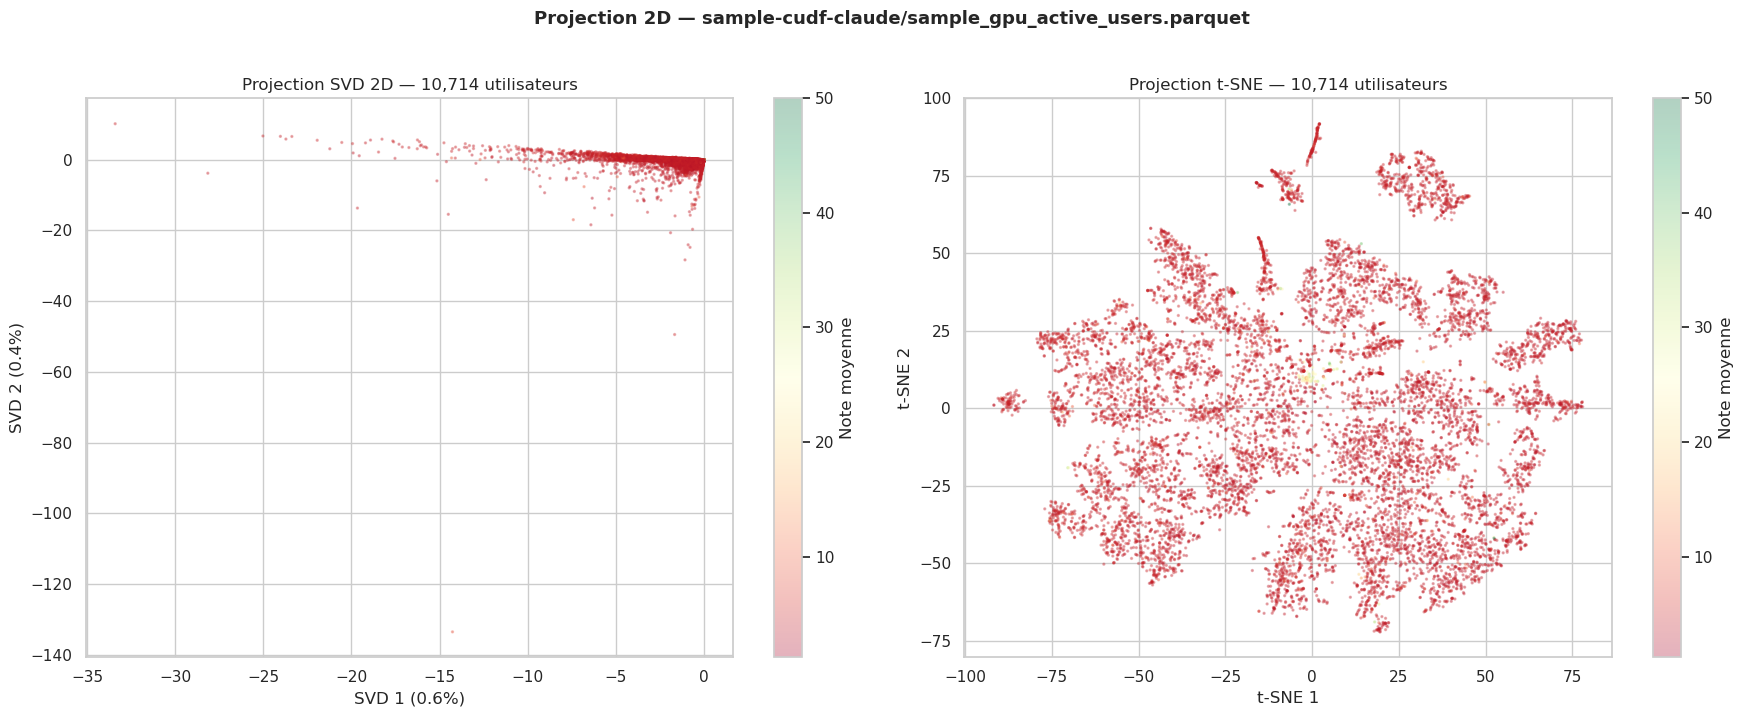

/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


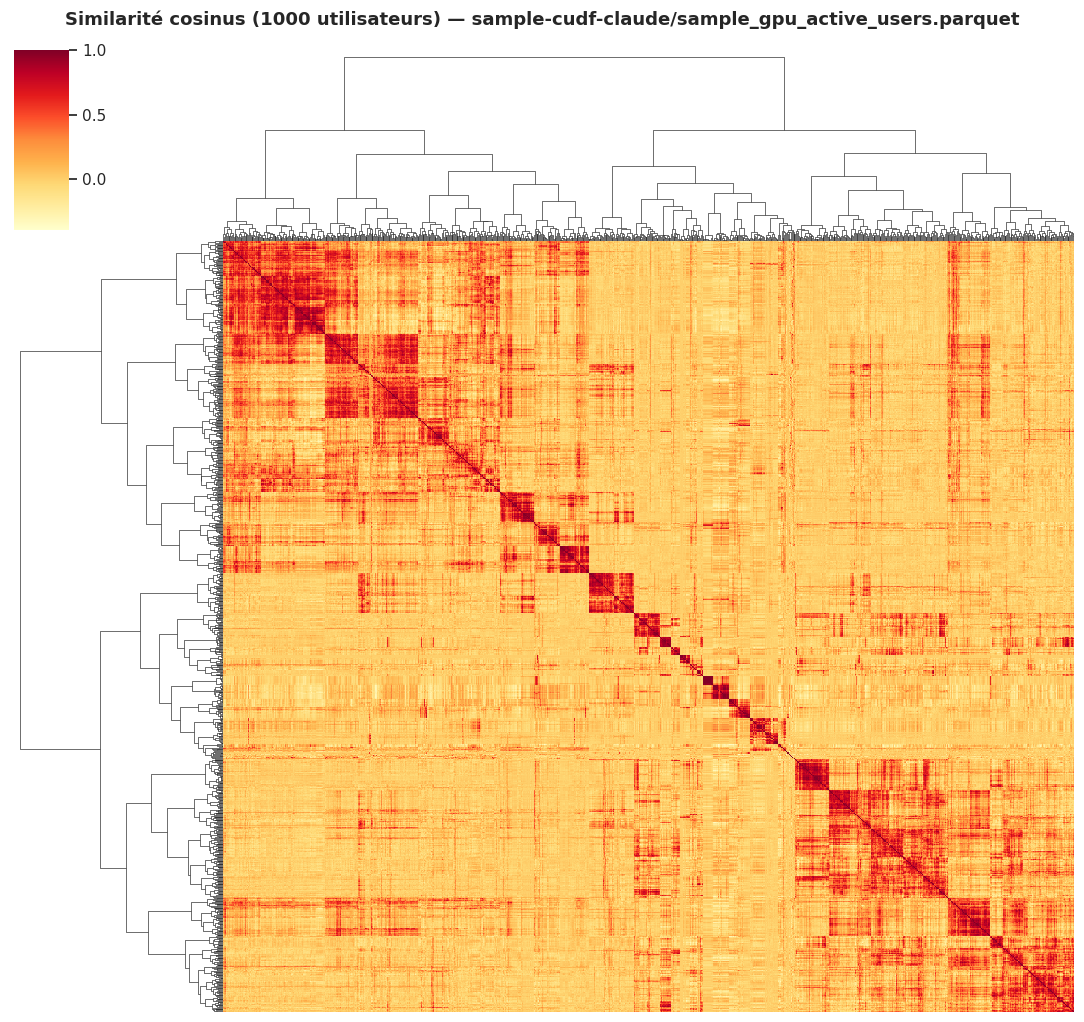

  Heatmap done (10.8s)


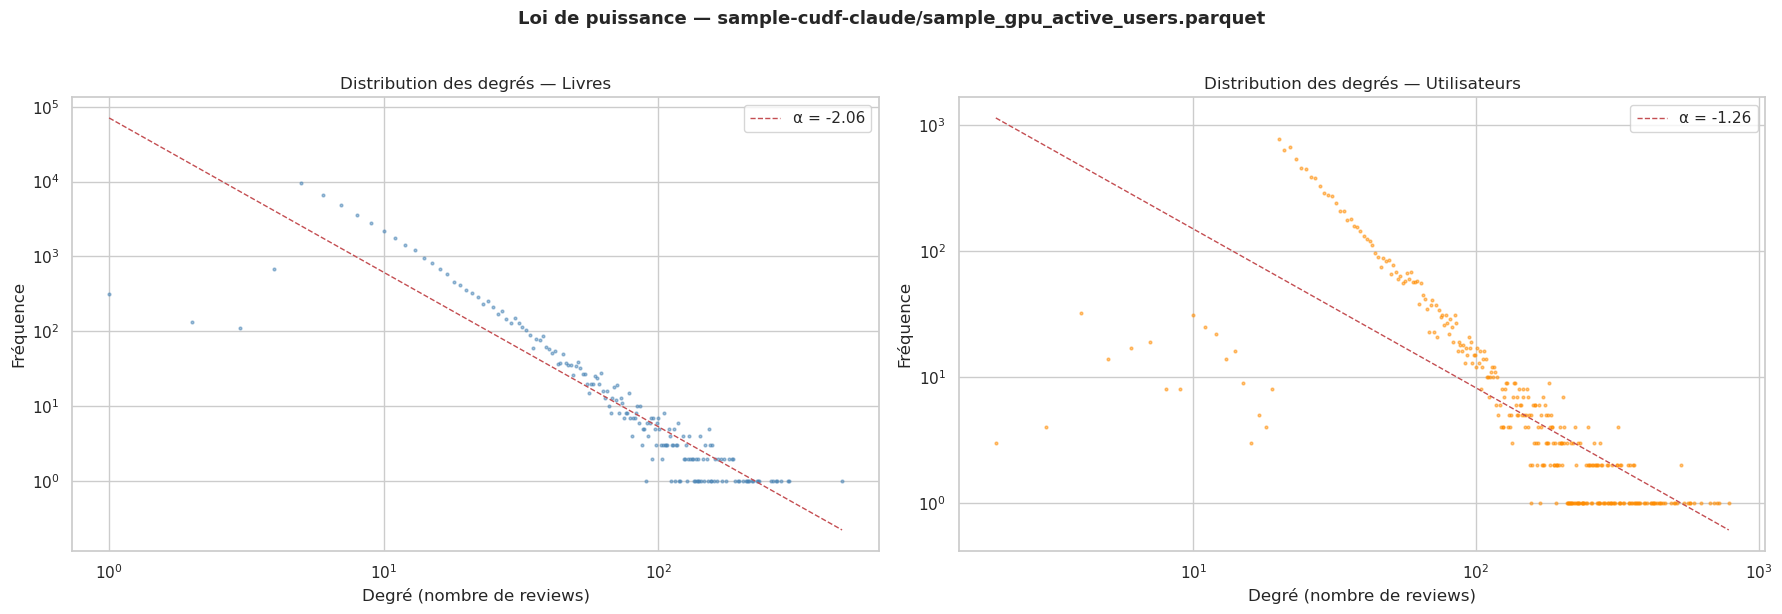

  Silhouette k=2..15 on 10,714 users...
    k= 2  silhouette=0.5825
    k= 3  silhouette=0.5675
    k= 4  silhouette=0.5314
    k= 5  silhouette=0.5170
    k= 6  silhouette=0.5155
    k= 7  silhouette=0.3254
    k= 8  silhouette=0.3343
    k= 9  silhouette=0.3300
    k=10  silhouette=0.3387
    k=11  silhouette=0.3237
    k=12  silhouette=0.3237
    k=13  silhouette=0.3062
    k=14  silhouette=0.2735
    k=15  silhouette=0.2734


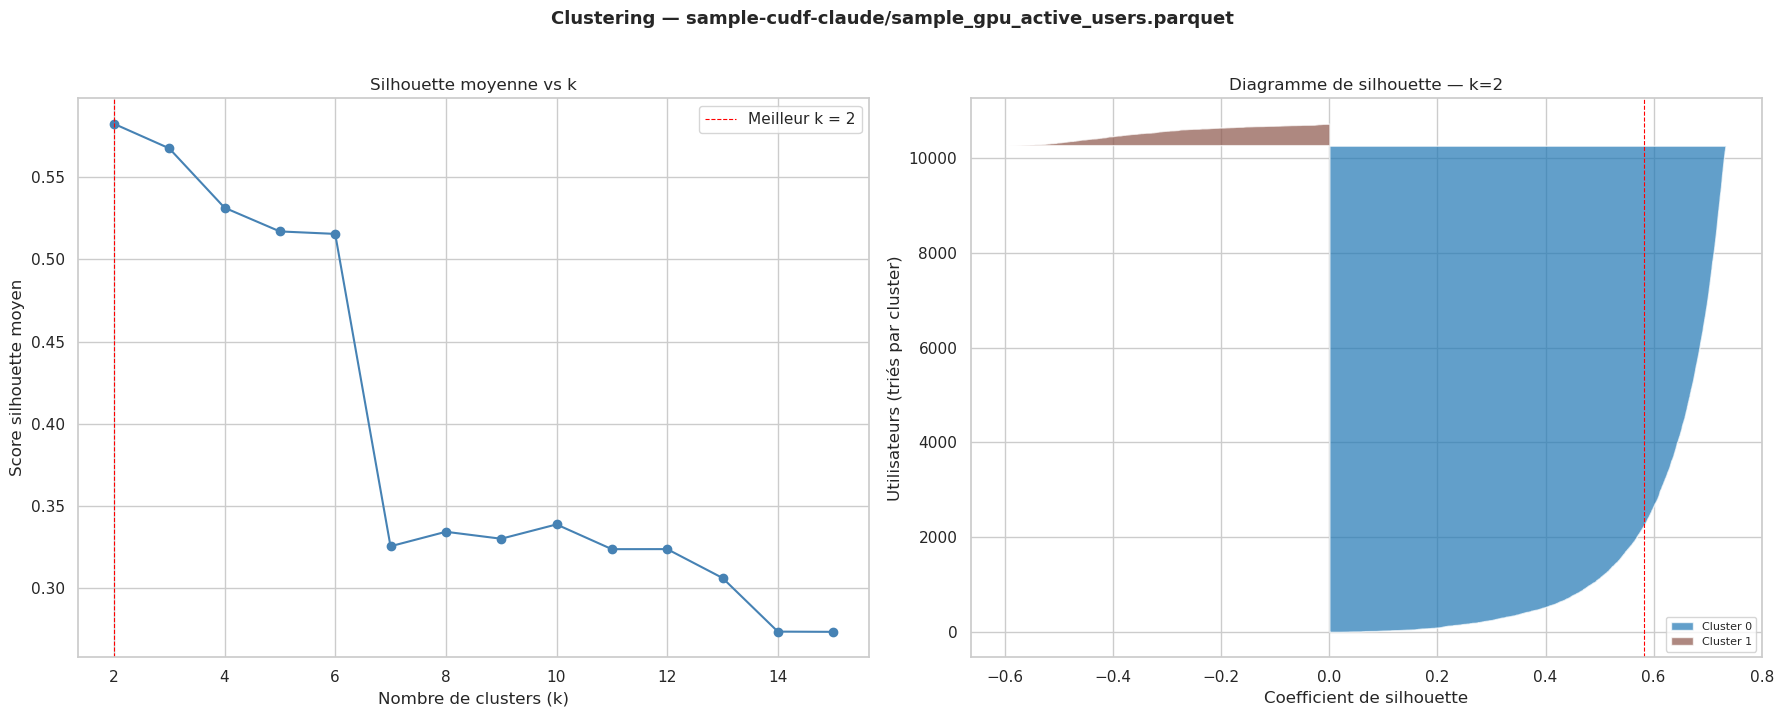

  Clustering done (28.6s)


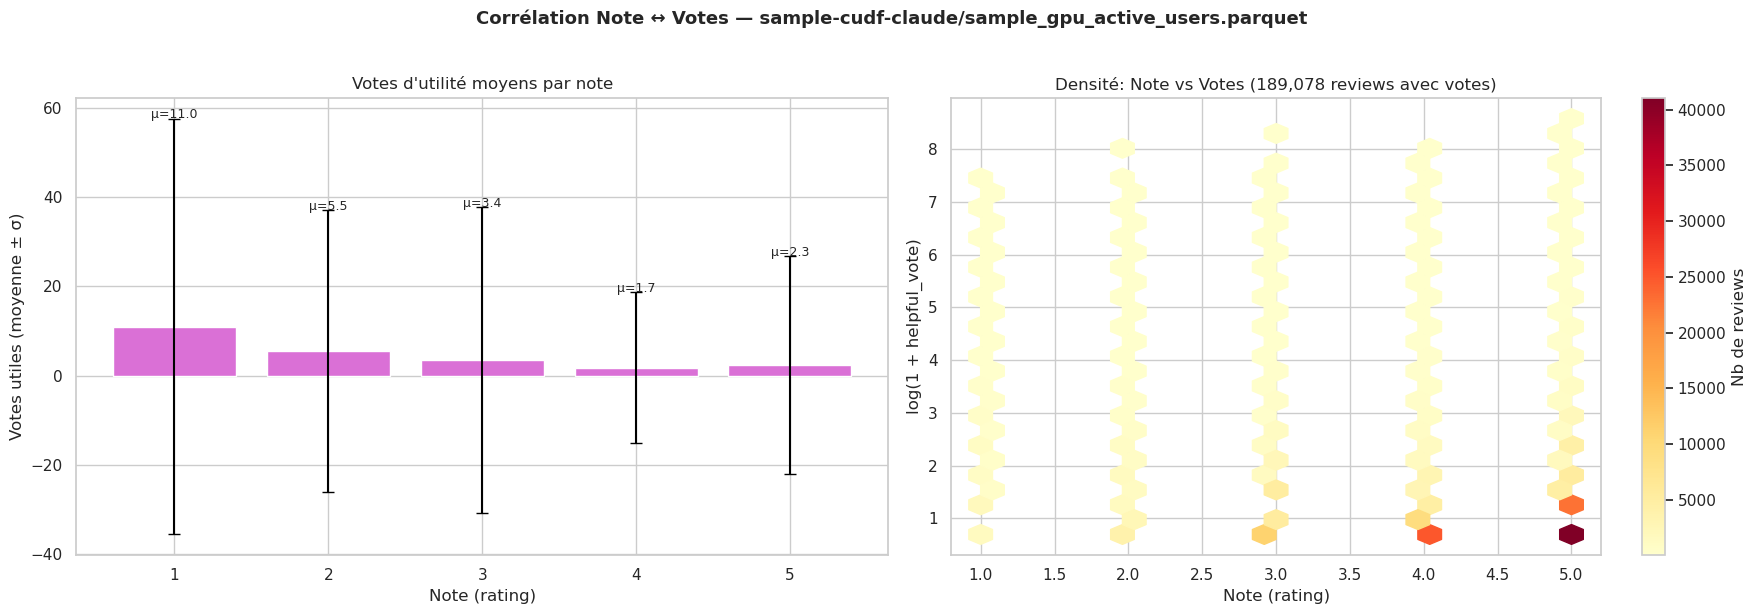


  Total: 28.7s

  Advanced Analysis — sample-cudf-tempor/sample_gpu_temporal.parquet
  Matrix: 6,739 × 22,007  (nnz=285,521, density=0.1925%)
  SVD: 50 comp, var=13.08% (0.1s)
  t-SNE on 6,739 users (CPU sklearn)...
  t-SNE done (5.8s)


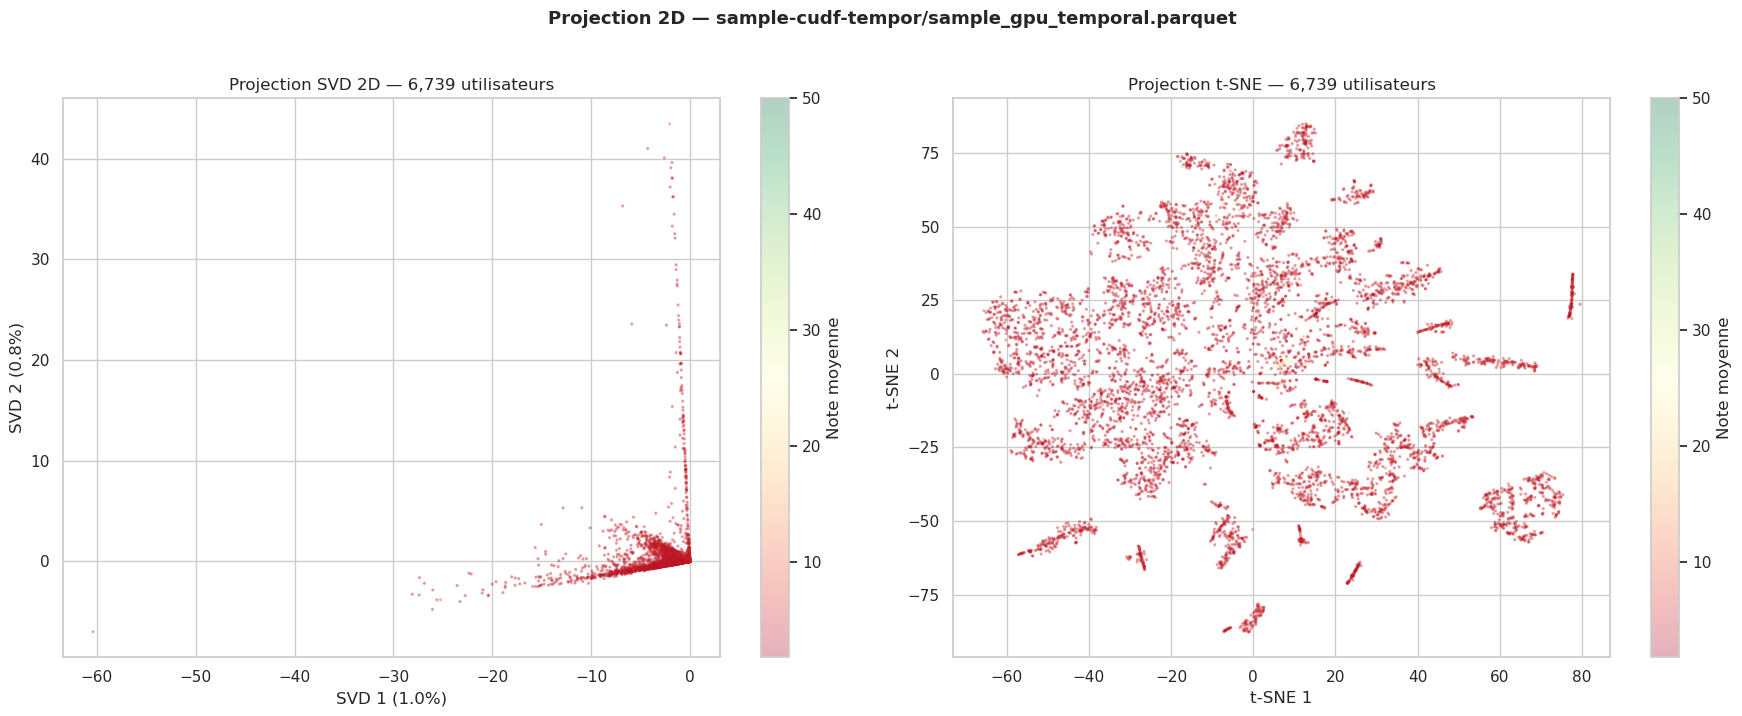

/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


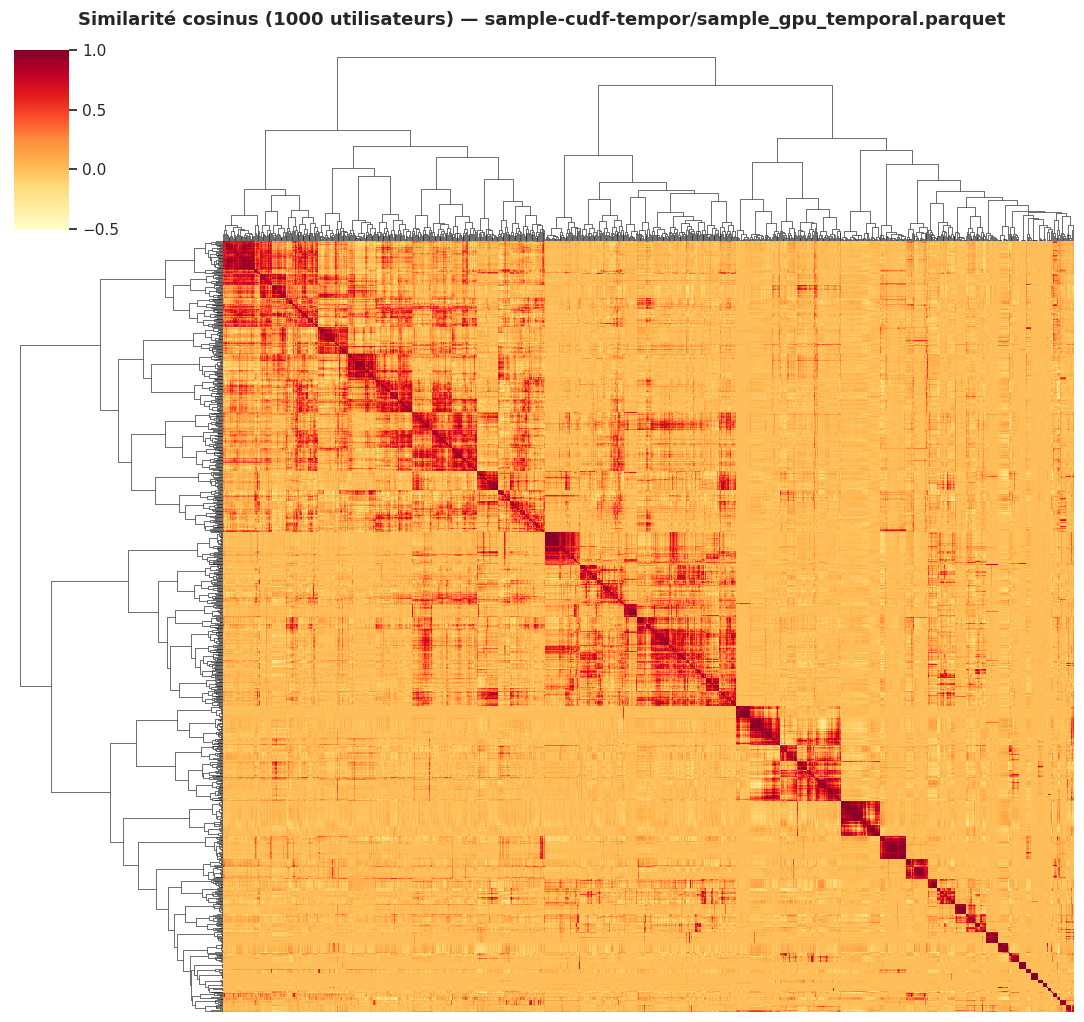

  Heatmap done (6.6s)


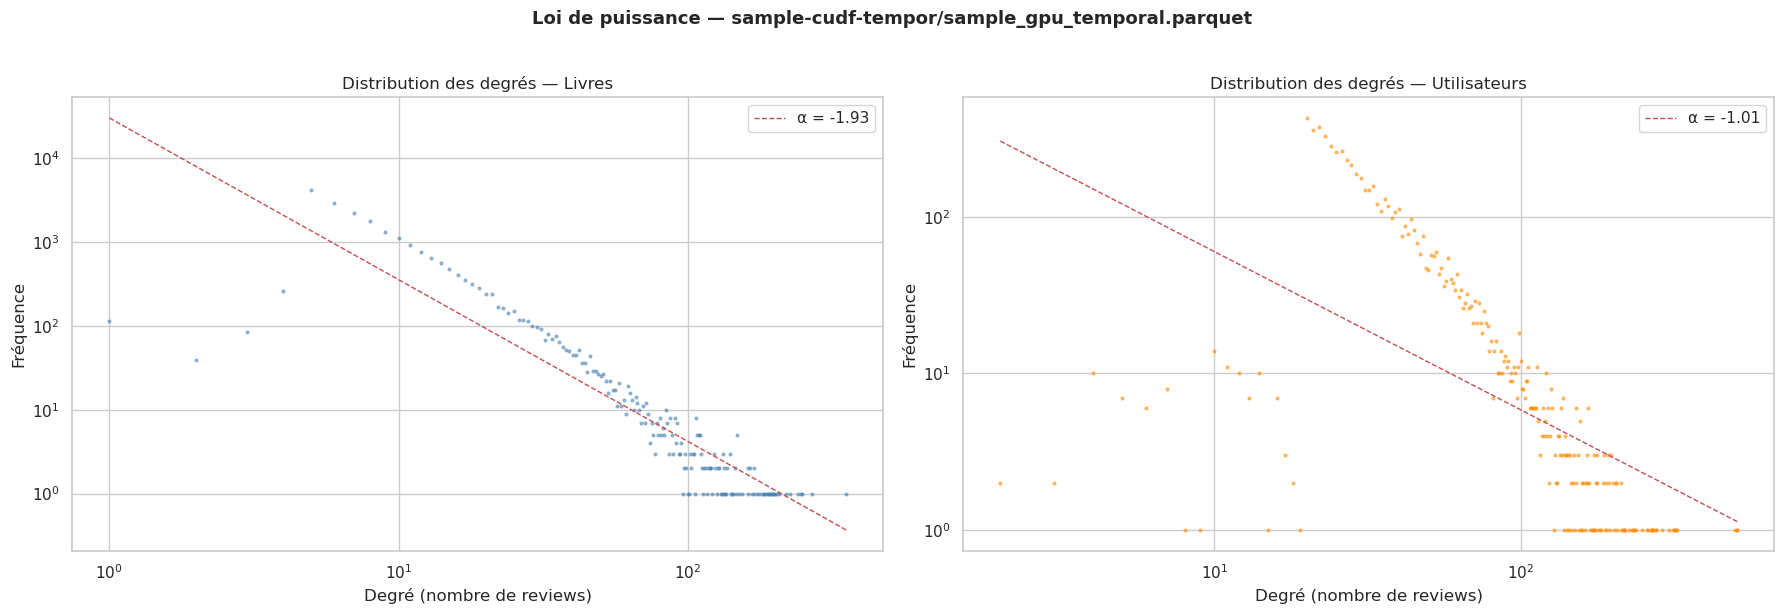

  Silhouette k=2..15 on 6,739 users...
    k= 2  silhouette=0.3435
    k= 3  silhouette=0.2745
    k= 4  silhouette=0.2530
    k= 5  silhouette=0.1417
    k= 6  silhouette=0.1457
    k= 7  silhouette=0.1198
    k= 8  silhouette=0.0876
    k= 9  silhouette=0.0923
    k=10  silhouette=0.1094
    k=11  silhouette=0.1184
    k=12  silhouette=0.1263
    k=13  silhouette=0.1321
    k=14  silhouette=0.1353
    k=15  silhouette=0.1270


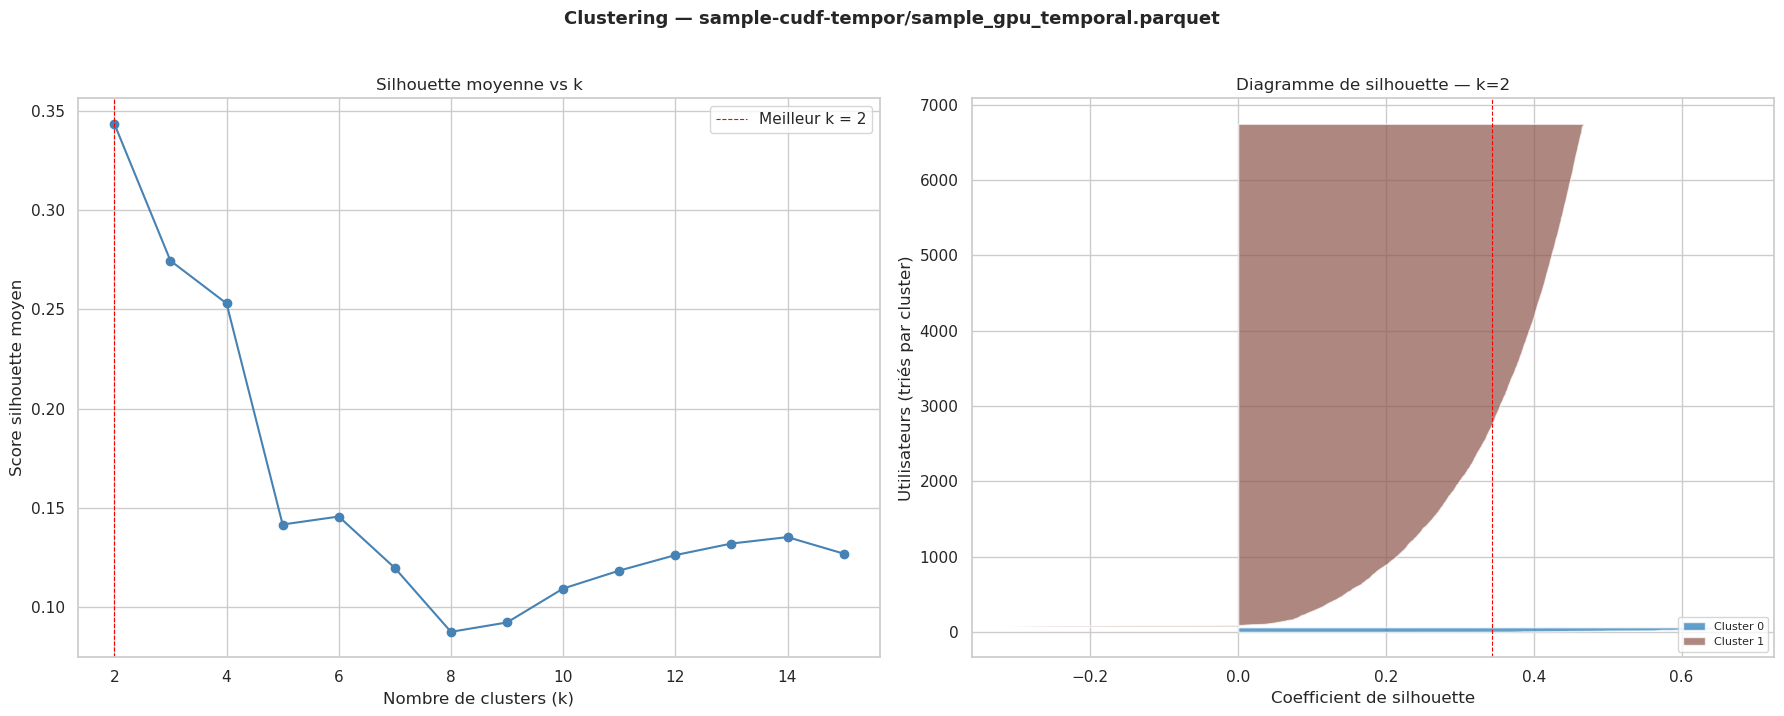

  Clustering done (14.5s)


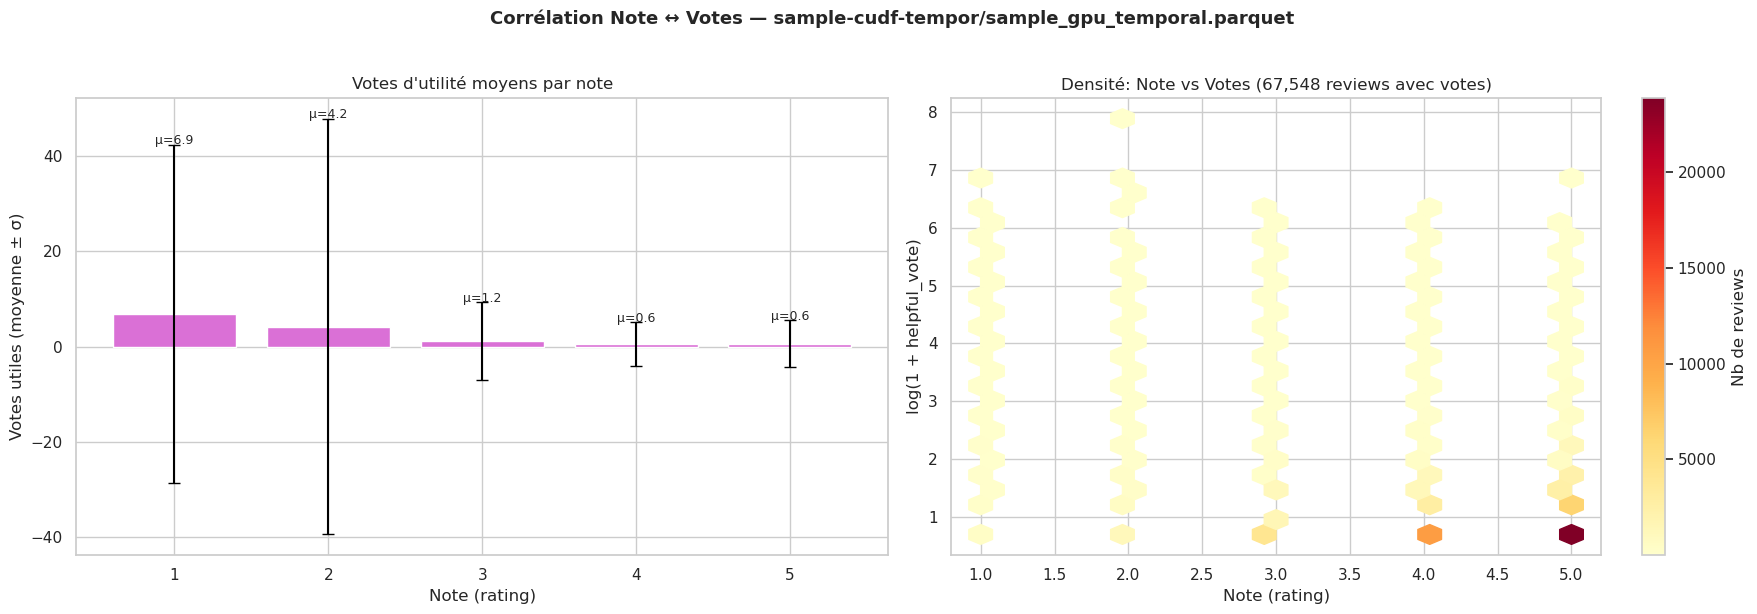


  Total: 14.7s


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix, coo_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
import gc, os, time
import torch
import glob

sns.set_theme(style="whitegrid")

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

# ── Backend detection ─────────────────────────────────────────
USE_GPU = torch.cuda.is_available()
if USE_GPU:
    GPU_DEV = torch.device("cuda")
    print(f"Backend: PyTorch GPU ({torch.cuda.get_device_name()})")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    GPU_DEV = torch.device("cpu")
    print("Backend: PyTorch CPU")

# ── Tunables ──────────────────────────────────────────────────
N_SVD_COMPONENTS   = 50
N_USERS_TSNE       = 50_000 if USE_GPU else 5_000
N_USERS_HEATMAP    = 1_000    if USE_GPU else 150
N_USERS_SILHOUETTE = 50_000 if USE_GPU else 8_000
N_SILHOUETTE_DETAIL = 20_000   # subsample for the detailed diagram only
K_RANGE            = range(2, 16) if USE_GPU else range(2, 11)

TARGET_SAMPLES = [
    "sample-cudf-claude/sample_gpu_active_users.parquet",
    "sample-cudf-tempor/sample_gpu_temporal.parquet",
]


# ── Helper: GPU KMeans via PyTorch ────────────────────────────
def torch_kmeans(X_np, n_clusters, max_iter=200, seed=42):
    torch.manual_seed(seed)
    X = torch.tensor(X_np, dtype=torch.float32, device=GPU_DEV)
    n = X.shape[0]
    idx = torch.randperm(n, device=GPU_DEV)[:n_clusters]
    centroids = X[idx].clone()

    for _ in range(max_iter):
        dists = torch.cdist(X, centroids)
        labels = dists.argmin(dim=1)
        new_centroids = torch.zeros_like(centroids)
        for j in range(n_clusters):
            mask = labels == j
            if mask.any():
                new_centroids[j] = X[mask].mean(dim=0)
            else:
                new_centroids[j] = X[torch.randint(n, (1,), device=GPU_DEV)].squeeze()
        if torch.allclose(centroids, new_centroids, atol=1e-6):
            break
        centroids = new_centroids

    return labels.cpu().numpy()


# ── Helper: sparse scipy → sparse torch on GPU ───────────────
def scipy_sparse_to_torch(sp_matrix, device):
    coo = coo_matrix(sp_matrix)
    indices = torch.tensor(
        np.array([coo.row, coo.col]), dtype=torch.long, device=device
    )
    values = torch.tensor(coo.data, dtype=torch.float32, device=device)
    return torch.sparse_coo_tensor(indices, values, size=coo.shape)


# ── Main loop ─────────────────────────────────────────────────
for path in SAMPLE_PATHS:
    # if TARGET_SAMPLES and path not in TARGET_SAMPLES:
    #     continue
    if os.path.getsize(path) < 1024:
        continue
    df = pd.read_parquet(path)
    if len(df) == 0:
        continue

    print(f"\n{'=' * 60}")
    print(f"  Advanced Analysis — {path}")
    print(f"{'=' * 60}")
    t0 = time.time()

    # ━━━ Sparse user-item matrix ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    user_enc = LabelEncoder()
    item_enc = LabelEncoder()
    uid = user_enc.fit_transform(df["user_id"])
    iid = item_enc.fit_transform(df["parent_asin"])

    R = csr_matrix(
        (df["rating"].values.astype(np.float32), (uid, iid)),
        shape=(len(user_enc.classes_), len(item_enc.classes_)),
    )
    n_users, n_items = R.shape
    print(f"  Matrix: {n_users:,} × {n_items:,}  "
          f"(nnz={R.nnz:,}, density={R.nnz / (n_users * n_items) * 100:.4f}%)")

    # ━━━ TruncatedSVD via torch.svd_lowrank ━━━━━━━━━━━━━━━━━━
    n_comp = min(N_SVD_COMPONENTS, n_users - 1, n_items - 1)

    if USE_GPU:
        R_torch = scipy_sparse_to_torch(R, GPU_DEV)
        U_t, S_t, V_t = torch.svd_lowrank(R_torch, q=n_comp, niter=5)

        U_svd = (U_t * S_t).cpu().numpy()

        total_var = float((R.data ** 2).sum())
        explained_var = float((S_t ** 2).sum())
        var_explained = explained_var / total_var
        var_ratios = (S_t ** 2 / total_var).cpu().numpy()

        del R_torch
        torch.cuda.empty_cache()
    else:
        from sklearn.decomposition import TruncatedSVD
        svd_cpu = TruncatedSVD(n_components=n_comp, random_state=42)
        U_svd = svd_cpu.fit_transform(R)
        var_explained = svd_cpu.explained_variance_ratio_.sum()
        var_ratios = svd_cpu.explained_variance_ratio_

    print(f"  SVD: {n_comp} comp, var={var_explained:.2%} ({time.time()-t0:.1f}s)")

    rng = np.random.default_rng(42)

    interactions = np.array((R > 0).sum(axis=1)).flatten()
    rating_sums  = np.array(R.sum(axis=1)).flatten()
    user_mean_rating = np.divide(
        rating_sums, interactions,
        out=np.zeros_like(rating_sums), where=interactions > 0,
    )

    # ━━━ VIZ 1 — 2D Projection (SVD + t-SNE) ━━━━━━━━━━━━━━━━
    n_tsne = min(N_USERS_TSNE, n_users)
    idx_tsne = rng.choice(n_users, size=n_tsne, replace=False)
    U_sub = U_svd[idx_tsne]
    colors = user_mean_rating[idx_tsne]

    fig1, axes1 = plt.subplots(1, 2, figsize=(18, 7))

    sc1 = axes1[0].scatter(
        U_sub[:, 0], U_sub[:, 1],
        c=colors, cmap="RdYlGn", s=2, alpha=0.3,
    )
    axes1[0].set_xlabel(f"SVD 1 ({var_ratios[0]:.1%})")
    axes1[0].set_ylabel(f"SVD 2 ({var_ratios[1]:.1%})")
    axes1[0].set_title(f"Projection SVD 2D — {n_tsne:,} utilisateurs")
    plt.colorbar(sc1, ax=axes1[0], label="Note moyenne")

    print(f"  t-SNE on {n_tsne:,} users (CPU sklearn)...")
    tsne = TSNE(
        n_components=2, perplexity=30, random_state=42,
        max_iter=1000, init="pca", learning_rate="auto",
    )
    U_tsne = tsne.fit_transform(U_sub)
    print(f"  t-SNE done ({time.time()-t0:.1f}s)")

    sc2 = axes1[1].scatter(
        U_tsne[:, 0], U_tsne[:, 1],
        c=colors, cmap="RdYlGn", s=2, alpha=0.3,
    )
    axes1[1].set_xlabel("t-SNE 1")
    axes1[1].set_ylabel("t-SNE 2")
    axes1[1].set_title(f"Projection t-SNE — {n_tsne:,} utilisateurs")
    plt.colorbar(sc2, ax=axes1[1], label="Note moyenne")

    plt.suptitle(f"Projection 2D — {path}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━ VIZ 2 — Similarity Heatmap ━━━━━━━━━━━━━━━━━━━━━━━━━
    n_hm = min(N_USERS_HEATMAP, n_users)
    idx_hm = rng.choice(n_users, size=n_hm, replace=False)

    if USE_GPU:
        hm_gpu = torch.tensor(U_svd[idx_hm], dtype=torch.float32, device=GPU_DEV)
        hm_norm = hm_gpu / hm_gpu.norm(dim=1, keepdim=True).clamp(min=1e-8)
        sim = (hm_norm @ hm_norm.T).cpu().numpy()
        del hm_gpu, hm_norm
        torch.cuda.empty_cache()
    else:
        sim = cosine_similarity(U_svd[idx_hm])

    g = sns.clustermap(
        sim, cmap="YlOrRd", figsize=(11, 10),
        xticklabels=False, yticklabels=False,
        method="ward", linewidths=0,
    )
    g.fig.suptitle(
        f"Similarité cosinus ({n_hm} utilisateurs) — {path}",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.show()
    print(f"  Heatmap done ({time.time()-t0:.1f}s)")

    # ━━━ VIZ 3 — Power-law degree distribution ━━━━━━━━━━━━━━━
    deg_items = np.array((R > 0).sum(axis=0)).flatten()
    deg_users = np.array((R > 0).sum(axis=1)).flatten()

    fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6))
    for ax, deg, label, color in [
        (axes3[0], deg_items[deg_items > 0], "Livres", "steelblue"),
        (axes3[1], deg_users[deg_users > 0], "Utilisateurs", "darkorange"),
    ]:
        vals, counts = np.unique(deg, return_counts=True)
        ax.loglog(vals, counts, ".", markersize=4, alpha=0.5, color=color)
        slope, intercept = np.polyfit(np.log10(vals), np.log10(counts), 1)
        x_fit = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 100)
        ax.loglog(x_fit, 10**intercept * x_fit**slope,
                  "r--", lw=1, label=f"α = {slope:.2f}")
        ax.set_xlabel("Degré (nombre de reviews)")
        ax.set_ylabel("Fréquence")
        ax.set_title(f"Distribution des degrés — {label}")
        ax.legend()

    plt.suptitle(f"Loi de puissance — {path}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━ VIZ 4 — Silhouette analysis ━━━━━━━━━━━━━━━━━━━━━━━━
    n_sil = min(N_USERS_SILHOUETTE, n_users)
    idx_sil = rng.choice(n_users, size=n_sil, replace=False)
    U_sil = U_svd[idx_sil]

    print(f"  Silhouette k={K_RANGE.start}..{K_RANGE.stop-1} on {n_sil:,} users...")
    sil_avgs = []
    for k in K_RANGE:
        if USE_GPU:
            labels = torch_kmeans(U_sil, n_clusters=k, seed=42)
        else:
            from sklearn.cluster import MiniBatchKMeans
            km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
            labels = km.fit_predict(U_sil)
        s = silhouette_score(U_sil, labels, sample_size=min(10_000, n_sil))
        sil_avgs.append(s)
        print(f"    k={k:2d}  silhouette={s:.4f}")

    best_k = list(K_RANGE)[int(np.argmax(sil_avgs))]

    fig4, axes4 = plt.subplots(1, 2, figsize=(18, 7))
    axes4[0].plot(list(K_RANGE), sil_avgs, "o-", color="steelblue", lw=1.5)
    axes4[0].axvline(best_k, color="red", ls="--", lw=0.8, label=f"Meilleur k = {best_k}")
    axes4[0].set_xlabel("Nombre de clusters (k)")
    axes4[0].set_ylabel("Score silhouette moyen")
    axes4[0].set_title("Silhouette moyenne vs k")
    axes4[0].legend()

    if USE_GPU:
        labels_best = torch_kmeans(U_sil, n_clusters=best_k, seed=42)
    else:
        km_best = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=2048)
        labels_best = km_best.fit_predict(U_sil)

    sample_sil = silhouette_samples(U_sil, labels_best)

    y_lower = 0
    for i in range(best_k):
        cluster_vals = np.sort(sample_sil[labels_best == i])
        y_upper = y_lower + len(cluster_vals)
        axes4[1].fill_betweenx(
            np.arange(y_lower, y_upper), 0, cluster_vals,
            facecolor=cm.tab10(i / best_k), alpha=0.7, label=f"Cluster {i}",
        )
        y_lower = y_upper + 10

    axes4[1].axvline(sil_avgs[best_k - K_RANGE.start], color="red", ls="--", lw=0.8)
    axes4[1].set_xlabel("Coefficient de silhouette")
    axes4[1].set_ylabel("Utilisateurs (triés par cluster)")
    axes4[1].set_title(f"Diagramme de silhouette — k={best_k}")
    axes4[1].legend(loc="lower right", fontsize=8)

    plt.suptitle(f"Clustering — {path}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"  Clustering done ({time.time()-t0:.1f}s)")

    # ━━━ VIZ 5 — Rating ↔ Helpful Votes ━━━━━━━━━━━━━━━━━━━━━
    fig5, axes5 = plt.subplots(1, 2, figsize=(18, 6))

    agg = (df.groupby("rating")["helpful_vote"]
             .agg(["mean", "median", "std"]).reset_index())

    axes5[0].bar(agg["rating"], agg["mean"], color="orchid", edgecolor="white")
    axes5[0].errorbar(agg["rating"], agg["mean"], yerr=agg["std"],
                      fmt="none", color="black", capsize=4)
    for _, row in agg.iterrows():
        axes5[0].text(row["rating"], row["mean"] + row["std"] + 0.1,
                      f'μ={row["mean"]:.1f}', ha="center", fontsize=9)
    axes5[0].set_xlabel("Note (rating)")
    axes5[0].set_ylabel("Votes utiles (moyenne ± σ)")
    axes5[0].set_title("Votes d'utilité moyens par note")
    axes5[0].set_xticks([1, 2, 3, 4, 5])

    df_nz = df[df["helpful_vote"] > 0]
    if len(df_nz) > 0:
        hb = axes5[1].hexbin(
            df_nz["rating"], np.log1p(df_nz["helpful_vote"]),
            gridsize=25, cmap="YlOrRd", mincnt=1,
        )
        plt.colorbar(hb, ax=axes5[1], label="Nb de reviews")
    axes5[1].set_xlabel("Note (rating)")
    axes5[1].set_ylabel("log(1 + helpful_vote)")
    axes5[1].set_title(f"Densité: Note vs Votes ({len(df_nz):,} reviews avec votes)")

    plt.suptitle(f"Corrélation Note ↔ Votes — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n  Total: {time.time()-t0:.1f}s")
    del df, R, U_svd, U_sil
    torch.cuda.empty_cache()
    gc.collect()

##### Non-cuml version with UMAP #####

Backend: PyTorch GPU (NVIDIA GeForce RTX 5090)
  VRAM: 33.7 GB
  Projection: UMAP (fast)

  ADVANCED ANALYSIS — sample-cudf-claude/sample_gpu_active_users.parquet

  [MATRIX] User-item rating matrix built:
    10,714 users × 43,926 books
    490,417 observed ratings (non-zero entries)
    Density: 0.1042%
    → 99.8958% of user-book pairs have NO rating (cold-start territory)

  [SVD] Dimensionality reduction (GPU: True):
    43,926-dim sparse → 50-dim dense per user
    Variance explained: 7.98%
    → A low % is normal for extremely sparse data. The top-50
      latent factors still capture the main structure.
    Time: 0.1s

  [VIZ 1] 2D Projection of 10,714 users
    Left: SVD (linear) — first 2 of 50 latent dimensions
    Right: UMAP (non-linear) — reveals local cluster structure
    Color encodes each user's mean rating (red=low, green=high)
    INTERPRETATION: Distinct clusters → users have different taste
    profiles → collaborative filtering is viable.


/usr/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    UMAP computed in 10.4s (CPU)


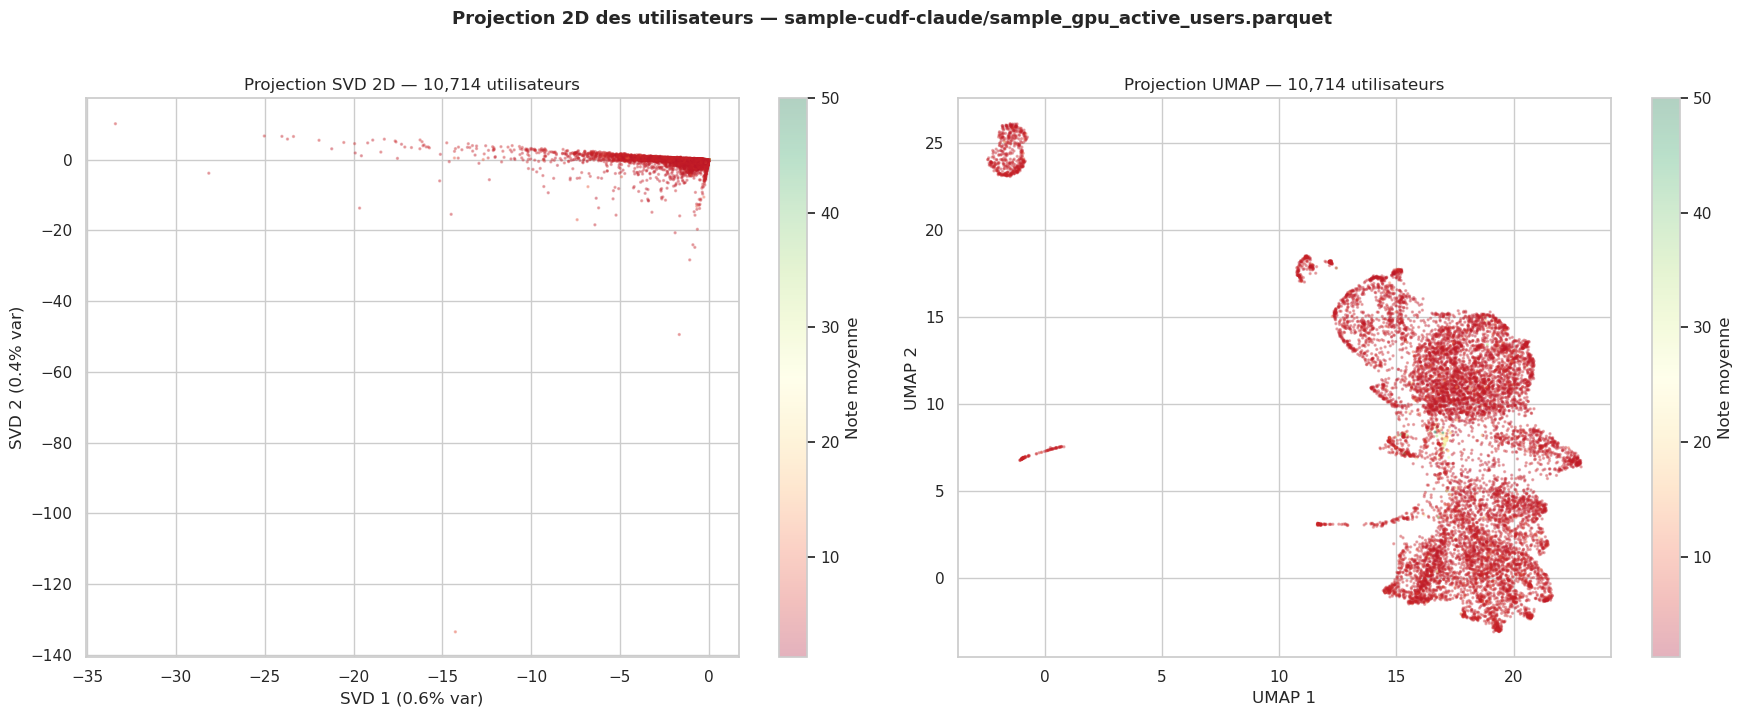


  [VIZ 2] Cosine similarity heatmap — 1000 users
    Computed on 50-dim SVD embeddings (GPU: True)
    Ward hierarchical clustering reorders rows/columns
    INTERPRETATION: Bright blocks along diagonal = user
    neighborhoods with similar reading preferences.
    More/larger blocks → richer structure for k-NN recommenders.


/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


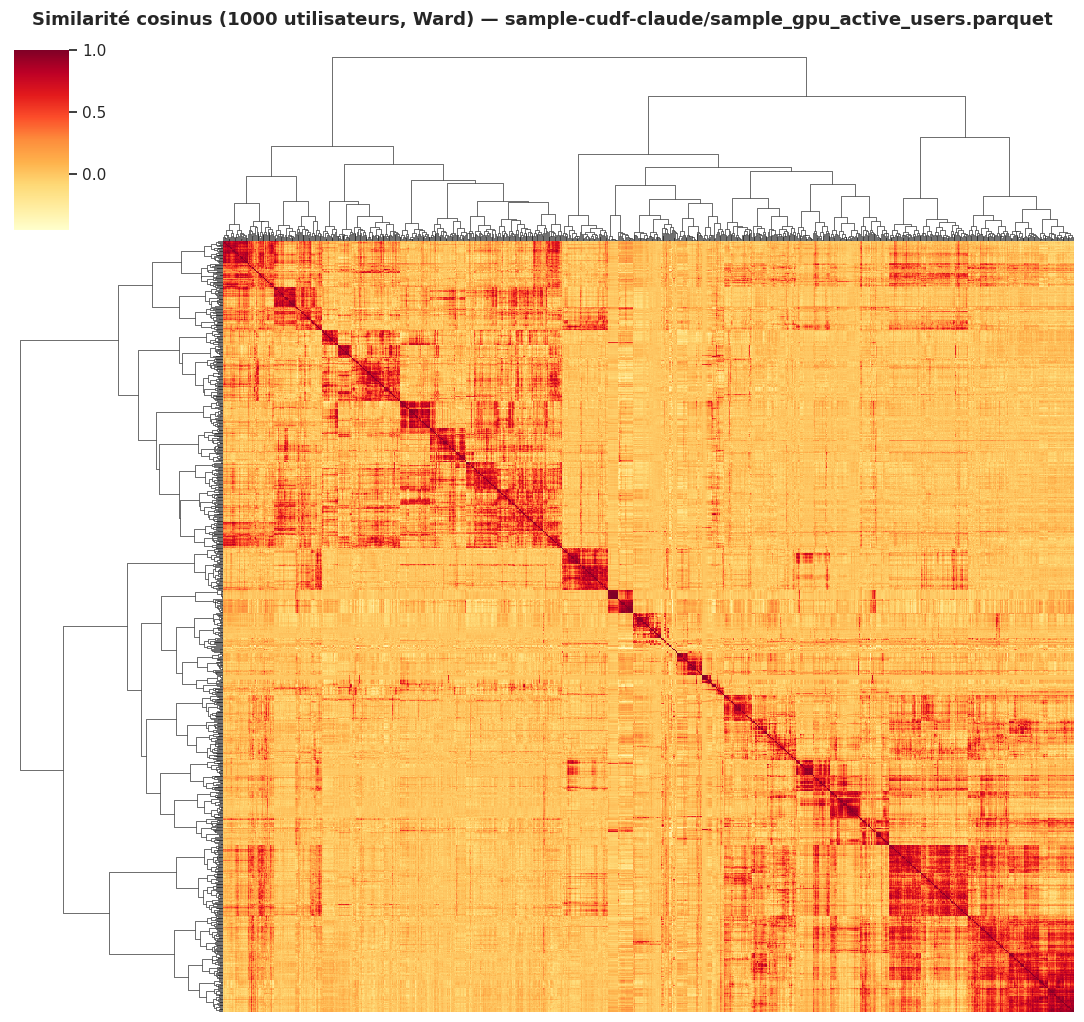

    Heatmap done (11.4s)

  [VIZ 3] Power-law degree distribution
    Left: books — how many books have k reviews?
    Right: users — how many users wrote k reviews?
    A linear fit on log-log gives the power-law exponent α.
    INTERPRETATION: More negative α = heavier long tail =
    more items/users with very few interactions (cold start).


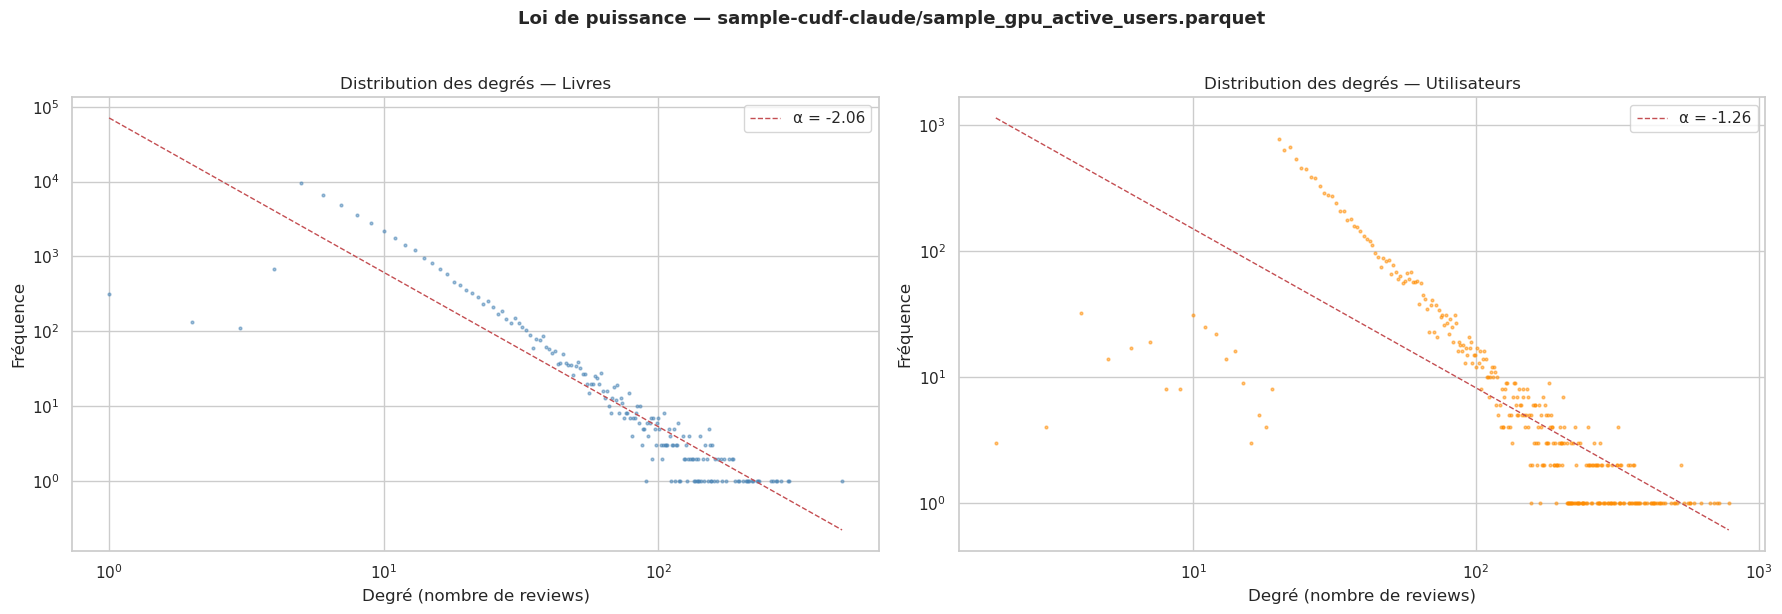


  [VIZ 4] Silhouette analysis — k=2..15
    Clustering 10,714 users in 50-dim SVD space
    KMeans on GPU, silhouette scoring on CPU
    INTERPRETATION: Peak silhouette score → optimal K.
    High silhouette (>0.5) → well-separated user profiles.
    This K can drive cluster-specific recommendation strategies.
      k= 2  silhouette=0.5714
      k= 3  silhouette=0.5865
      k= 4  silhouette=0.5687
      k= 5  silhouette=0.5503
      k= 6  silhouette=0.5456
      k= 7  silhouette=0.3236
      k= 8  silhouette=0.3382
      k= 9  silhouette=0.3306
      k=10  silhouette=0.3228
      k=11  silhouette=0.3214
      k=12  silhouette=0.3174
      k=13  silhouette=0.3327
      k=14  silhouette=0.2798
      k=15  silhouette=0.2805
    → Best k = 3 (silhouette = 0.5865)


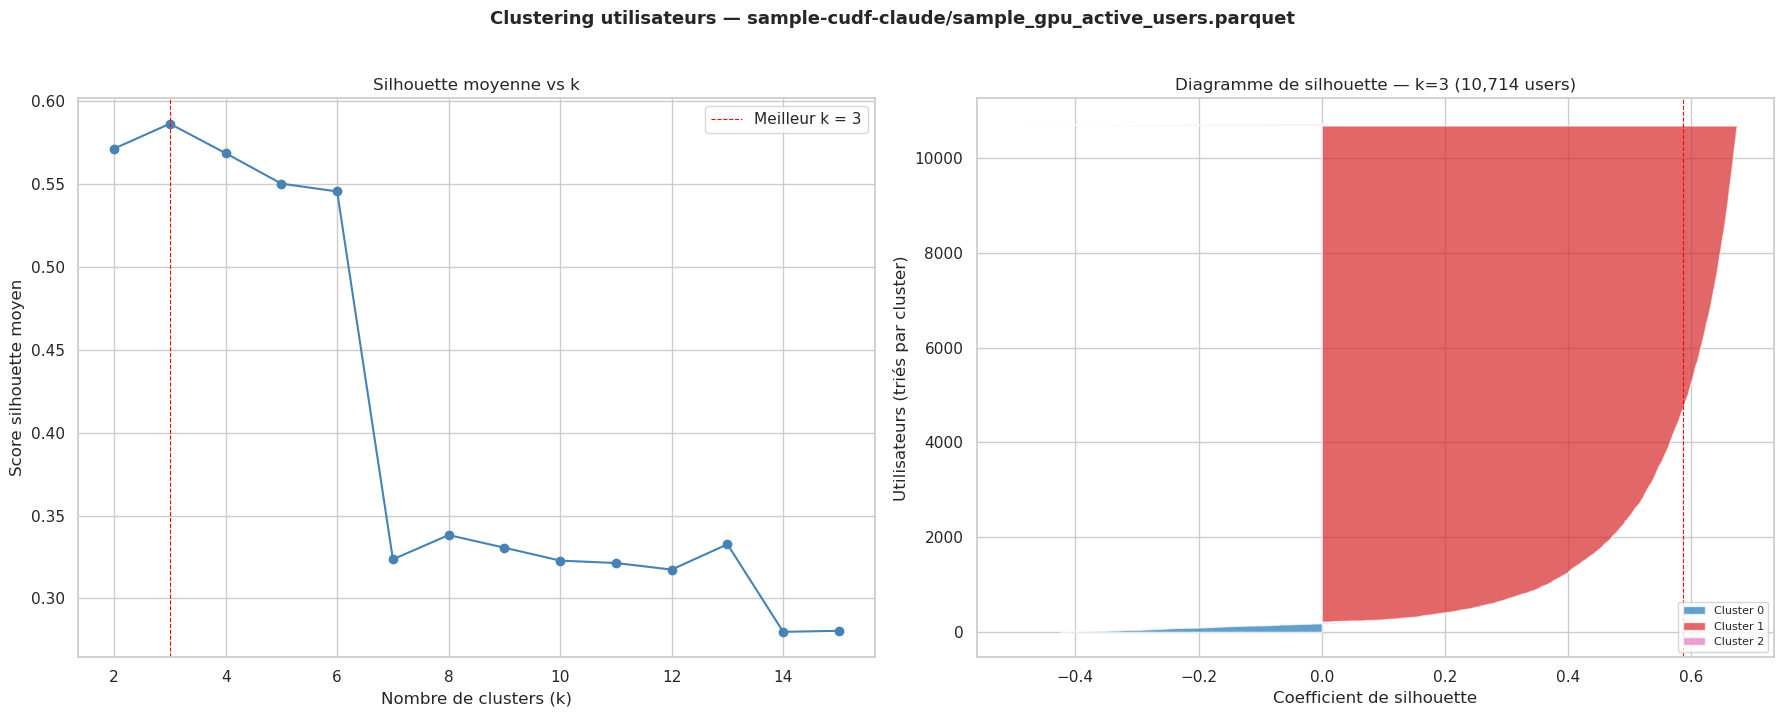

    Clustering done (28.2s)

  [VIZ 5] Rating vs Helpful Votes correlation
    Left: average helpful votes per rating level (1-5 stars)
    Right: density plot for reviews with ≥1 vote
    INTERPRETATION: If extreme ratings (1★, 5★) get more votes,
    the community finds polarized opinions more useful — this
    signal could weight reviews in a recommendation model.


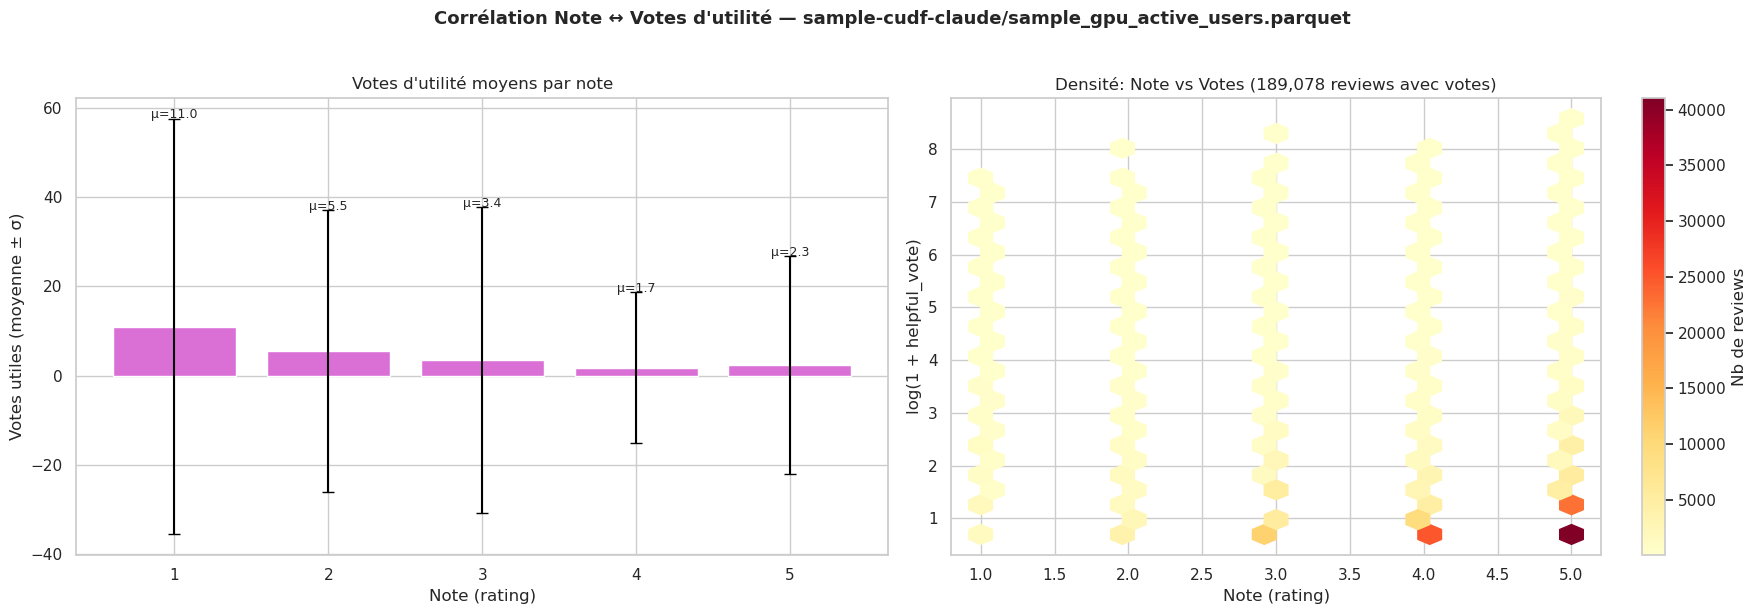


  TOTAL: 28.4s


  ADVANCED ANALYSIS — sample-cudf-tempor/sample_gpu_temporal.parquet

  [MATRIX] User-item rating matrix built:
    6,739 users × 22,007 books
    285,521 observed ratings (non-zero entries)
    Density: 0.1925%
    → 99.8075% of user-book pairs have NO rating (cold-start territory)

  [SVD] Dimensionality reduction (GPU: True):
    22,007-dim sparse → 50-dim dense per user
    Variance explained: 13.08%
    → A low % is normal for extremely sparse data. The top-50
      latent factors still capture the main structure.
    Time: 0.1s

  [VIZ 1] 2D Projection of 6,739 users
    Left: SVD (linear) — first 2 of 50 latent dimensions
    Right: UMAP (non-linear) — reveals local cluster structure
    Color encodes each user's mean rating (red=low, green=high)
    INTERPRETATION: Distinct clusters → users have different taste
    profiles → collaborative filtering is viable.


/usr/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    UMAP computed in 8.7s (CPU)


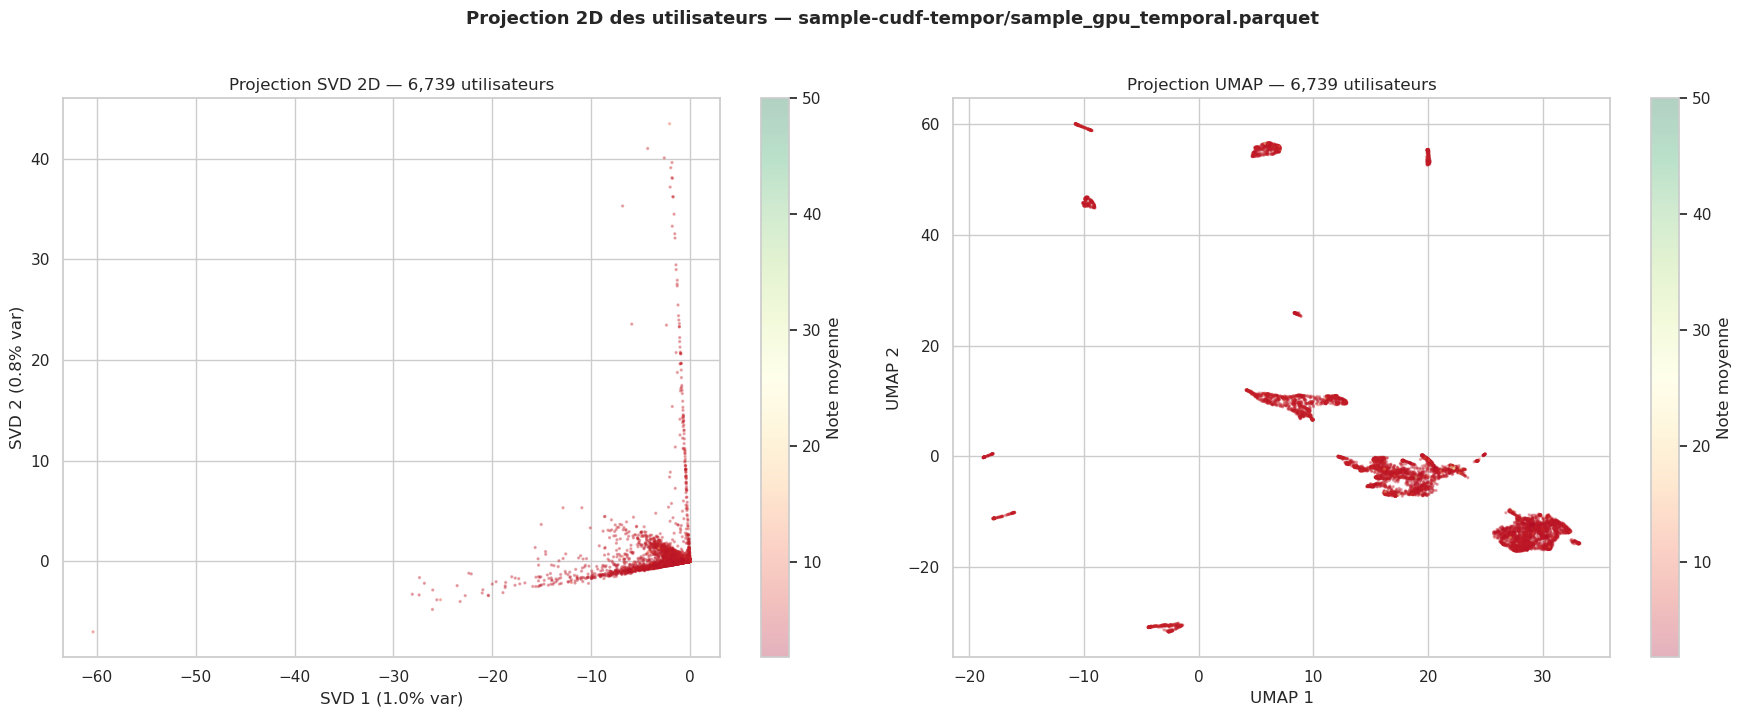


  [VIZ 2] Cosine similarity heatmap — 1000 users
    Computed on 50-dim SVD embeddings (GPU: True)
    Ward hierarchical clustering reorders rows/columns
    INTERPRETATION: Bright blocks along diagonal = user
    neighborhoods with similar reading preferences.
    More/larger blocks → richer structure for k-NN recommenders.


/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


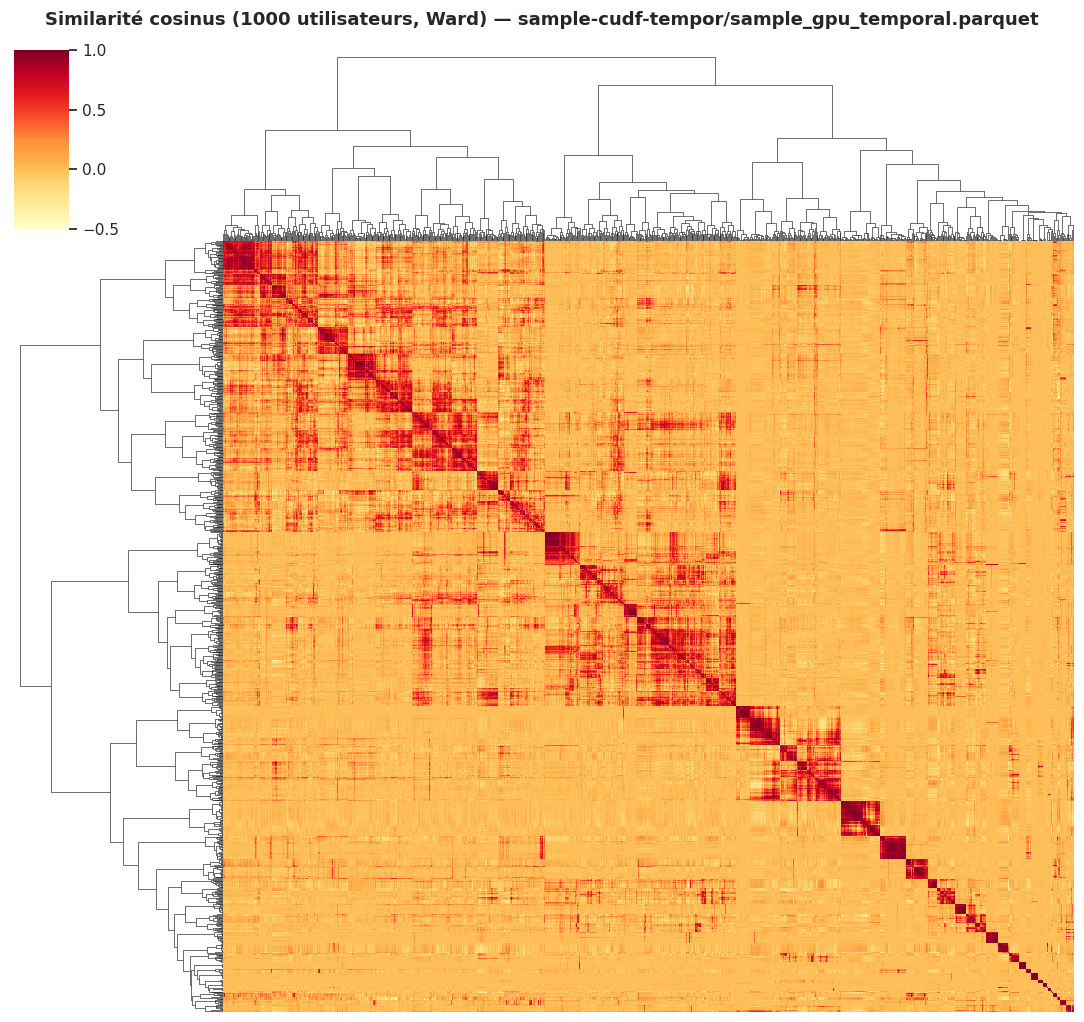

    Heatmap done (9.5s)

  [VIZ 3] Power-law degree distribution
    Left: books — how many books have k reviews?
    Right: users — how many users wrote k reviews?
    A linear fit on log-log gives the power-law exponent α.
    INTERPRETATION: More negative α = heavier long tail =
    more items/users with very few interactions (cold start).


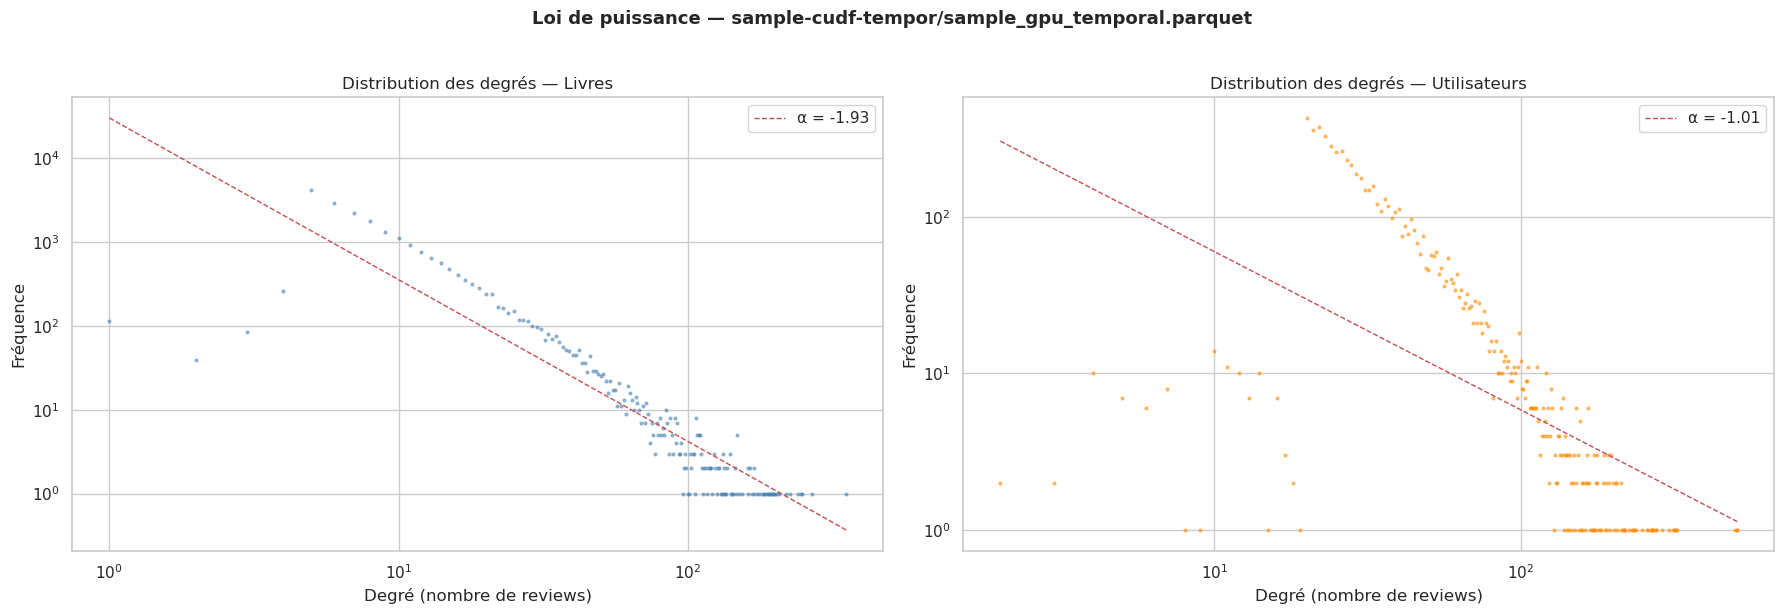


  [VIZ 4] Silhouette analysis — k=2..15
    Clustering 6,739 users in 50-dim SVD space
    KMeans on GPU, silhouette scoring on CPU
    INTERPRETATION: Peak silhouette score → optimal K.
    High silhouette (>0.5) → well-separated user profiles.
    This K can drive cluster-specific recommendation strategies.
      k= 2  silhouette=0.3435
      k= 3  silhouette=0.2745
      k= 4  silhouette=0.2530
      k= 5  silhouette=0.1417
      k= 6  silhouette=0.1457
      k= 7  silhouette=0.1198
      k= 8  silhouette=0.0876
      k= 9  silhouette=0.0923
      k=10  silhouette=0.1094
      k=11  silhouette=0.1184
      k=12  silhouette=0.1263
      k=13  silhouette=0.1321
      k=14  silhouette=0.1353
      k=15  silhouette=0.1270
    → Best k = 2 (silhouette = 0.3435)


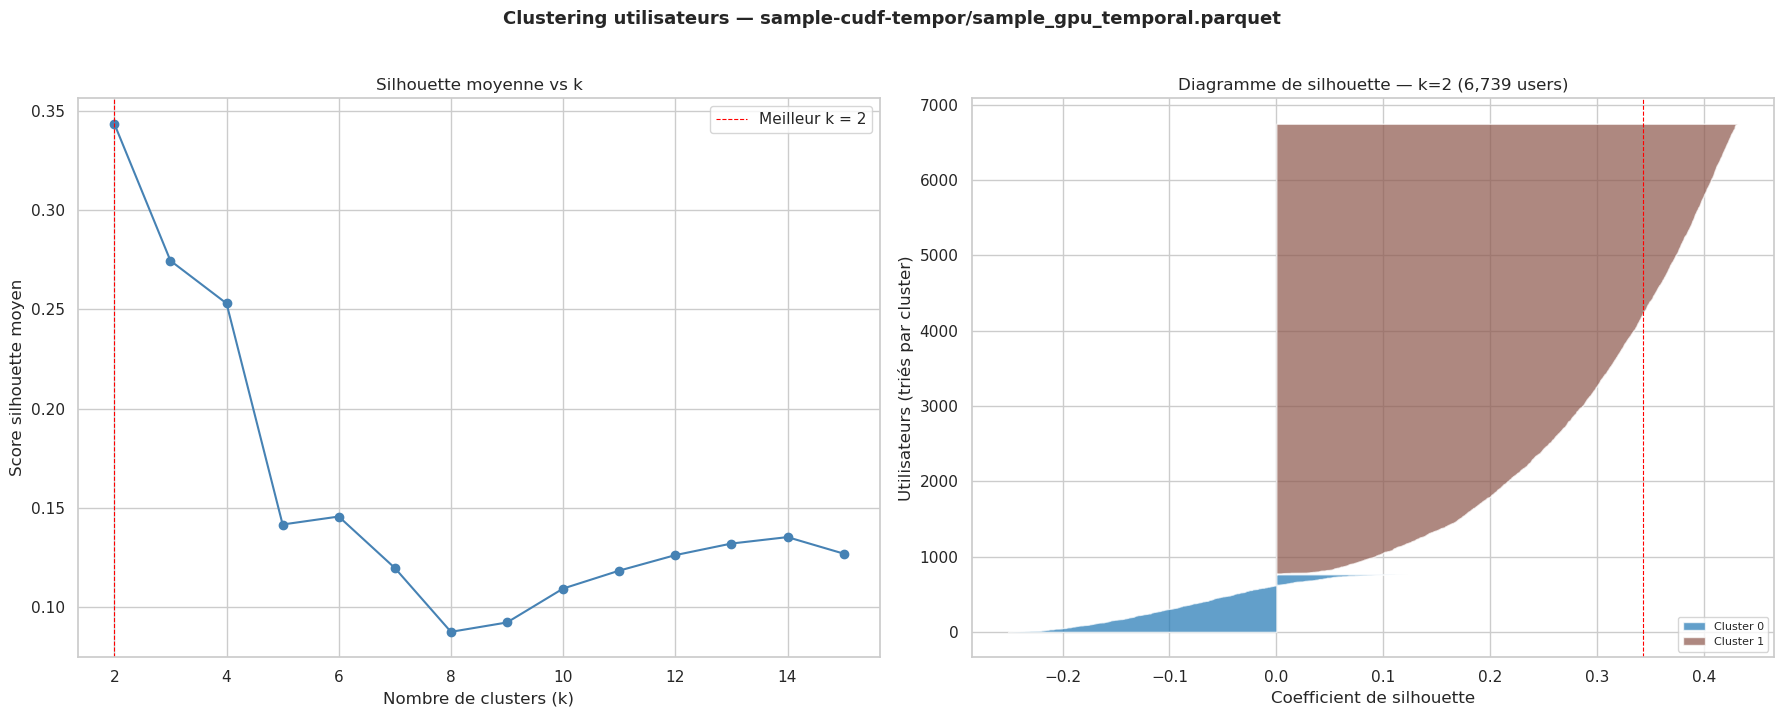

    Clustering done (17.3s)

  [VIZ 5] Rating vs Helpful Votes correlation
    Left: average helpful votes per rating level (1-5 stars)
    Right: density plot for reviews with ≥1 vote
    INTERPRETATION: If extreme ratings (1★, 5★) get more votes,
    the community finds polarized opinions more useful — this
    signal could weight reviews in a recommendation model.


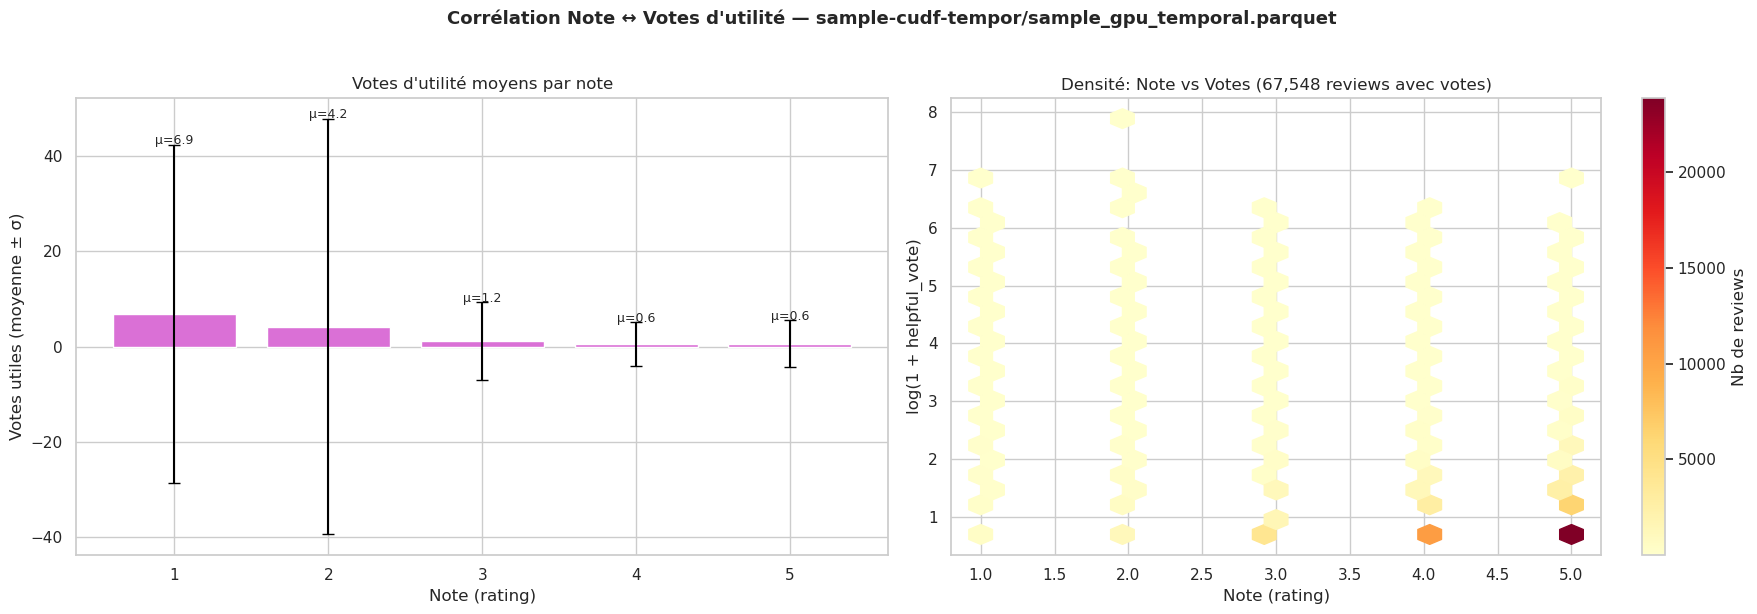


  TOTAL: 17.4s



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix, coo_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
import gc, os, time
import torch
import glob

sns.set_theme(style="whitegrid")

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

# ── Backend detection ─────────────────────────────────────────
USE_GPU = torch.cuda.is_available()
if USE_GPU:
    GPU_DEV = torch.device("cuda")
    print(f"Backend: PyTorch GPU ({torch.cuda.get_device_name()})")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    GPU_DEV = torch.device("cpu")
    print("Backend: PyTorch CPU")

# ── Tunables ──────────────────────────────────────────────────
N_SVD_COMPONENTS    = 50
N_USERS_PROJ        = 50_000 if USE_GPU else 5_000
N_USERS_HEATMAP     = 1_000  if USE_GPU else 150
N_USERS_SILHOUETTE  = 50_000 if USE_GPU else 8_000
N_SILHOUETTE_DETAIL = 20_000
K_RANGE             = range(2, 16) if USE_GPU else range(2, 11)

TARGET_SAMPLES = [
    "sample-cudf-claude/sample_gpu_active_users.parquet",
    "sample-cudf-tempor/sample_gpu_temporal.parquet",
]

# Try to import UMAP (much faster than t-SNE); fall back to t-SNE
try:
    from umap import UMAP
    HAS_UMAP = True
    print("  Projection: UMAP (fast)")
except ImportError:
    HAS_UMAP = False
    print("  Projection: t-SNE (slower, `pip install umap-learn` for speed)")


def torch_kmeans(X_np, n_clusters, max_iter=200, seed=42):
    """KMeans on GPU via torch.cdist for distance computation."""
    torch.manual_seed(seed)
    X = torch.tensor(X_np, dtype=torch.float32, device=GPU_DEV)
    n = X.shape[0]
    idx = torch.randperm(n, device=GPU_DEV)[:n_clusters]
    centroids = X[idx].clone()

    for _ in range(max_iter):
        dists = torch.cdist(X, centroids)
        labels = dists.argmin(dim=1)
        new_centroids = torch.zeros_like(centroids)
        for j in range(n_clusters):
            mask = labels == j
            if mask.any():
                new_centroids[j] = X[mask].mean(dim=0)
            else:
                new_centroids[j] = X[torch.randint(n, (1,), device=GPU_DEV)].squeeze()
        if torch.allclose(centroids, new_centroids, atol=1e-6):
            break
        centroids = new_centroids

    return labels.cpu().numpy()


def scipy_sparse_to_torch(sp_matrix, device):
    """Zero-copy conversion: scipy COO sparse -> torch sparse tensor on GPU."""
    coo = coo_matrix(sp_matrix)
    indices = torch.tensor(
        np.array([coo.row, coo.col]), dtype=torch.long, device=device
    )
    values = torch.tensor(coo.data, dtype=torch.float32, device=device)
    return torch.sparse_coo_tensor(indices, values, size=coo.shape)


for path in SAMPLE_PATHS:
    # if TARGET_SAMPLES and path not in TARGET_SAMPLES:
    #     continue
    if os.path.getsize(path) < 1024:
        continue
    df = pd.read_parquet(path)
    if len(df) == 0:
        continue

    print(f"\n{'=' * 70}")
    print(f"  ADVANCED ANALYSIS — {path}")
    print(f"{'=' * 70}")
    t0 = time.time()

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  STEP 0 — Build sparse user-item rating matrix
    #  Rows = users, Columns = books, Values = ratings (1-5).
    #  Most entries are zero (unobserved), hence sparse representation.
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    user_enc = LabelEncoder()
    item_enc = LabelEncoder()
    uid = user_enc.fit_transform(df["user_id"])
    iid = item_enc.fit_transform(df["parent_asin"])

    R = csr_matrix(
        (df["rating"].values.astype(np.float32), (uid, iid)),
        shape=(len(user_enc.classes_), len(item_enc.classes_)),
    )
    n_users, n_items = R.shape

    print(f"\n  [MATRIX] User-item rating matrix built:")
    print(f"    {n_users:,} users × {n_items:,} books")
    print(f"    {R.nnz:,} observed ratings (non-zero entries)")
    print(f"    Density: {R.nnz / (n_users * n_items) * 100:.4f}%")
    print(f"    → {100 - R.nnz / (n_users * n_items) * 100:.4f}% of user-book "
          f"pairs have NO rating (cold-start territory)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  STEP 1 — Dimensionality reduction: TruncatedSVD
    #  Reduce each user from a ~1M-dimensional sparse vector to a
    #  dense 50-dimensional embedding. This captures the dominant
    #  latent factors (reading preferences).
    #  Uses torch.svd_lowrank on GPU for speed on sparse tensors.
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_comp = min(N_SVD_COMPONENTS, n_users - 1, n_items - 1)

    if USE_GPU:
        R_torch = scipy_sparse_to_torch(R, GPU_DEV)
        U_t, S_t, V_t = torch.svd_lowrank(R_torch, q=n_comp, niter=5)
        U_svd = (U_t * S_t).cpu().numpy()
        total_var = float((R.data ** 2).sum())
        explained_var = float((S_t ** 2).sum())
        var_explained = explained_var / total_var
        var_ratios = (S_t ** 2).cpu().numpy() / total_var
        del R_torch, U_t, S_t, V_t
        torch.cuda.empty_cache()
    else:
        from sklearn.decomposition import TruncatedSVD
        svd_cpu = TruncatedSVD(n_components=n_comp, random_state=42)
        U_svd = svd_cpu.fit_transform(R)
        var_explained = svd_cpu.explained_variance_ratio_.sum()
        var_ratios = svd_cpu.explained_variance_ratio_

    print(f"\n  [SVD] Dimensionality reduction (GPU: {USE_GPU}):")
    print(f"    {n_items:,}-dim sparse → {n_comp}-dim dense per user")
    print(f"    Variance explained: {var_explained:.2%}")
    print(f"    → A low % is normal for extremely sparse data. The top-{n_comp}")
    print(f"      latent factors still capture the main structure.")
    print(f"    Time: {time.time()-t0:.1f}s")

    rng = np.random.default_rng(42)

    # Per-user mean rating (for coloring projections)
    interactions = np.array((R > 0).sum(axis=1)).flatten()
    rating_sums  = np.array(R.sum(axis=1)).flatten()
    user_mean_rating = np.divide(
        rating_sums, interactions,
        out=np.zeros_like(rating_sums), where=interactions > 0,
    )

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 1 — 2D User Projection (SVD first 2 dims + UMAP/t-SNE)
    #
    #  PURPOSE: Identify visual clusters of readers. If users group
    #  into "bubbles", it validates that collaborative filtering or
    #  clustering-based recommendations can find meaningful segments.
    #  Left panel: raw SVD components (linear projection).
    #  Right panel: UMAP or t-SNE (non-linear, preserves local
    #  neighborhoods — better at revealing cluster structure).
    #  Color = mean rating: green=generous raters, red=harsh raters.
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_proj = min(N_USERS_PROJ, n_users)
    idx_proj = rng.choice(n_users, size=n_proj, replace=False)
    U_sub = U_svd[idx_proj]
    colors = user_mean_rating[idx_proj]

    print(f"\n  [VIZ 1] 2D Projection of {n_proj:,} users")
    print(f"    Left: SVD (linear) — first 2 of {n_comp} latent dimensions")
    print(f"    Right: {'UMAP' if HAS_UMAP else 't-SNE'} (non-linear) — "
          f"reveals local cluster structure")
    print(f"    Color encodes each user's mean rating (red=low, green=high)")
    print(f"    INTERPRETATION: Distinct clusters → users have different taste")
    print(f"    profiles → collaborative filtering is viable.")

    fig1, axes1 = plt.subplots(1, 2, figsize=(18, 7))

    sc1 = axes1[0].scatter(
        U_sub[:, 0], U_sub[:, 1],
        c=colors, cmap="RdYlGn", s=2, alpha=0.3,
    )
    axes1[0].set_xlabel(f"SVD 1 ({var_ratios[0]:.1%} var)")
    axes1[0].set_ylabel(f"SVD 2 ({var_ratios[1]:.1%} var)")
    axes1[0].set_title(f"Projection SVD 2D — {n_proj:,} utilisateurs")
    plt.colorbar(sc1, ax=axes1[0], label="Note moyenne")

    t_proj = time.time()
    if HAS_UMAP:
        reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.3,
                       random_state=42, n_jobs=-1)
        U_2d = reducer.fit_transform(U_sub)
        proj_label = "UMAP"
    else:
        tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                    max_iter=1000, init="pca", learning_rate="auto")
        U_2d = tsne.fit_transform(U_sub)
        proj_label = "t-SNE"
    print(f"    {proj_label} computed in {time.time()-t_proj:.1f}s (CPU)")

    sc2 = axes1[1].scatter(
        U_2d[:, 0], U_2d[:, 1],
        c=colors, cmap="RdYlGn", s=2, alpha=0.3,
    )
    axes1[1].set_xlabel(f"{proj_label} 1")
    axes1[1].set_ylabel(f"{proj_label} 2")
    axes1[1].set_title(f"Projection {proj_label} — {n_proj:,} utilisateurs")
    plt.colorbar(sc2, ax=axes1[1], label="Note moyenne")

    plt.suptitle(f"Projection 2D des utilisateurs — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 2 — User Similarity Heatmap (cosine similarity)
    #
    #  PURPOSE: Detect neighborhood structure. Rows and columns are
    #  users, reordered by hierarchical clustering (Ward linkage).
    #  Dense yellow/red blocks on the diagonal = groups of users
    #  with highly correlated tastes → "neighborhoods" that k-NN
    #  recommendation can exploit.
    #  Cosine similarity computed on GPU via normalized matmul.
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_hm = min(N_USERS_HEATMAP, n_users)
    idx_hm = rng.choice(n_users, size=n_hm, replace=False)

    print(f"\n  [VIZ 2] Cosine similarity heatmap — {n_hm} users")
    print(f"    Computed on {n_comp}-dim SVD embeddings (GPU: {USE_GPU})")
    print(f"    Ward hierarchical clustering reorders rows/columns")
    print(f"    INTERPRETATION: Bright blocks along diagonal = user")
    print(f"    neighborhoods with similar reading preferences.")
    print(f"    More/larger blocks → richer structure for k-NN recommenders.")

    if USE_GPU:
        hm_gpu = torch.tensor(U_svd[idx_hm], dtype=torch.float32, device=GPU_DEV)
        hm_norm = hm_gpu / hm_gpu.norm(dim=1, keepdim=True).clamp(min=1e-8)
        sim = (hm_norm @ hm_norm.T).cpu().numpy()
        del hm_gpu, hm_norm
        torch.cuda.empty_cache()
    else:
        sim = cosine_similarity(U_svd[idx_hm])

    g = sns.clustermap(
        sim, cmap="YlOrRd", figsize=(11, 10),
        xticklabels=False, yticklabels=False,
        method="ward", linewidths=0,
    )
    g.fig.suptitle(
        f"Similarité cosinus ({n_hm} utilisateurs, Ward) — {path}",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.show()
    print(f"    Heatmap done ({time.time()-t0:.1f}s)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 3 — Power-law degree distribution (log-log)
    #
    #  PURPOSE: Visualize the "long tail" phenomenon precisely.
    #  X-axis: degree (# reviews a book received, or # reviews a
    #  user wrote). Y-axis: how many books/users have that degree.
    #  A straight line on log-log scale = power law.
    #  Slope α characterizes the tail: more negative = heavier tail.
    #  Typical real-world: α between -1.5 and -3.
    #  This matters because most books have very few reviews
    #  (cold start), while a few blockbusters dominate.
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    deg_items = np.array((R > 0).sum(axis=0)).flatten()
    deg_users = np.array((R > 0).sum(axis=1)).flatten()

    print(f"\n  [VIZ 3] Power-law degree distribution")
    print(f"    Left: books — how many books have k reviews?")
    print(f"    Right: users — how many users wrote k reviews?")
    print(f"    A linear fit on log-log gives the power-law exponent α.")
    print(f"    INTERPRETATION: More negative α = heavier long tail =")
    print(f"    more items/users with very few interactions (cold start).")

    fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6))
    for ax, deg, label, color in [
        (axes3[0], deg_items[deg_items > 0], "Livres", "steelblue"),
        (axes3[1], deg_users[deg_users > 0], "Utilisateurs", "darkorange"),
    ]:
        vals, counts = np.unique(deg, return_counts=True)
        ax.loglog(vals, counts, ".", markersize=4, alpha=0.5, color=color)
        slope, intercept = np.polyfit(np.log10(vals), np.log10(counts), 1)
        x_fit = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 100)
        ax.loglog(x_fit, 10**intercept * x_fit**slope,
                  "r--", lw=1, label=f"α = {slope:.2f}")
        ax.set_xlabel("Degré (nombre de reviews)")
        ax.set_ylabel("Fréquence")
        ax.set_title(f"Distribution des degrés — {label}")
        ax.legend()

    plt.suptitle(f"Loi de puissance — {path}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 4 — Silhouette analysis for user clustering
    #
    #  PURPOSE: Determine the optimal number of user profiles (K).
    #  KMeans groups users into K clusters in the SVD embedding space.
    #  The silhouette score [-1, 1] measures cluster cohesion vs
    #  separation: higher = tighter, more distinct clusters.
    #  Left panel: avg silhouette vs K → pick the peak.
    #  Right panel: per-user silhouette at optimal K → wide positive
    #  bars = well-assigned users; negative = misclassified.
    #  KMeans runs on GPU (torch_kmeans), silhouette on CPU (sklearn).
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    n_sil = min(N_USERS_SILHOUETTE, n_users)
    idx_sil = rng.choice(n_users, size=n_sil, replace=False)
    U_sil = U_svd[idx_sil]

    print(f"\n  [VIZ 4] Silhouette analysis — k={K_RANGE.start}..{K_RANGE.stop-1}")
    print(f"    Clustering {n_sil:,} users in {n_comp}-dim SVD space")
    print(f"    KMeans on GPU, silhouette scoring on CPU")
    print(f"    INTERPRETATION: Peak silhouette score → optimal K.")
    print(f"    High silhouette (>0.5) → well-separated user profiles.")
    print(f"    This K can drive cluster-specific recommendation strategies.")

    sil_avgs = []
    for k in K_RANGE:
        if USE_GPU:
            labels = torch_kmeans(U_sil, n_clusters=k, seed=42)
        else:
            from sklearn.cluster import MiniBatchKMeans
            km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
            labels = km.fit_predict(U_sil)
        s = silhouette_score(U_sil, labels, sample_size=min(10_000, n_sil))
        sil_avgs.append(s)
        print(f"      k={k:2d}  silhouette={s:.4f}")

    best_k = list(K_RANGE)[int(np.argmax(sil_avgs))]
    print(f"    → Best k = {best_k} (silhouette = {max(sil_avgs):.4f})")

    fig4, axes4 = plt.subplots(1, 2, figsize=(18, 7))
    axes4[0].plot(list(K_RANGE), sil_avgs, "o-", color="steelblue", lw=1.5)
    axes4[0].axvline(best_k, color="red", ls="--", lw=0.8, label=f"Meilleur k = {best_k}")
    axes4[0].set_xlabel("Nombre de clusters (k)")
    axes4[0].set_ylabel("Score silhouette moyen")
    axes4[0].set_title("Silhouette moyenne vs k")
    axes4[0].legend()

    # Detailed silhouette diagram on a subsample (O(n²) cost)
    n_detail = min(N_SILHOUETTE_DETAIL, n_sil)
    idx_detail = rng.choice(n_sil, size=n_detail, replace=False)
    U_detail = U_sil[idx_detail]

    if USE_GPU:
        labels_detail = torch_kmeans(U_detail, n_clusters=best_k, seed=42)
    else:
        km_best = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=2048)
        labels_detail = km_best.fit_predict(U_detail)

    sample_sil = silhouette_samples(U_detail, labels_detail)

    y_lower = 0
    for i in range(best_k):
        cluster_vals = np.sort(sample_sil[labels_detail == i])
        y_upper = y_lower + len(cluster_vals)
        axes4[1].fill_betweenx(
            np.arange(y_lower, y_upper), 0, cluster_vals,
            facecolor=cm.tab10(i / best_k), alpha=0.7, label=f"Cluster {i}",
        )
        y_lower = y_upper + 10

    axes4[1].axvline(sil_avgs[best_k - K_RANGE.start], color="red", ls="--", lw=0.8)
    axes4[1].set_xlabel("Coefficient de silhouette")
    axes4[1].set_ylabel("Utilisateurs (triés par cluster)")
    axes4[1].set_title(f"Diagramme de silhouette — k={best_k} ({n_detail:,} users)")
    axes4[1].legend(loc="lower right", fontsize=8)

    plt.suptitle(f"Clustering utilisateurs — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"    Clustering done ({time.time()-t0:.1f}s)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  VIZ 5 — Correlation: Rating ↔ Helpful Votes
    #
    #  PURPOSE: Investigate whether extreme ratings (1 or 5 stars)
    #  attract more "helpful" votes from the community.
    #  Left panel: mean helpful votes per rating level (with std bars).
    #  Right panel: 2D density (hexbin) of rating vs log(helpful_vote)
    #  for reviews that received at least one vote.
    #  If low-star reviews get more votes, they carry a stronger
    #  quality signal and could be weighted higher in training.
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    print(f"\n  [VIZ 5] Rating vs Helpful Votes correlation")
    print(f"    Left: average helpful votes per rating level (1-5 stars)")
    print(f"    Right: density plot for reviews with ≥1 vote")
    print(f"    INTERPRETATION: If extreme ratings (1★, 5★) get more votes,")
    print(f"    the community finds polarized opinions more useful — this")
    print(f"    signal could weight reviews in a recommendation model.")

    fig5, axes5 = plt.subplots(1, 2, figsize=(18, 6))

    agg = (df.groupby("rating")["helpful_vote"]
             .agg(["mean", "median", "std"]).reset_index())

    axes5[0].bar(agg["rating"], agg["mean"], color="orchid", edgecolor="white")
    axes5[0].errorbar(agg["rating"], agg["mean"], yerr=agg["std"],
                      fmt="none", color="black", capsize=4)
    for _, row in agg.iterrows():
        axes5[0].text(row["rating"], row["mean"] + row["std"] + 0.1,
                      f'μ={row["mean"]:.1f}', ha="center", fontsize=9)
    axes5[0].set_xlabel("Note (rating)")
    axes5[0].set_ylabel("Votes utiles (moyenne ± σ)")
    axes5[0].set_title("Votes d'utilité moyens par note")
    axes5[0].set_xticks([1, 2, 3, 4, 5])

    df_nz = df[df["helpful_vote"] > 0]
    if len(df_nz) > 0:
        hb = axes5[1].hexbin(
            df_nz["rating"], np.log1p(df_nz["helpful_vote"]),
            gridsize=25, cmap="YlOrRd", mincnt=1,
        )
        plt.colorbar(hb, ax=axes5[1], label="Nb de reviews")
    axes5[1].set_xlabel("Note (rating)")
    axes5[1].set_ylabel("log(1 + helpful_vote)")
    axes5[1].set_title(f"Densité: Note vs Votes ({len(df_nz):,} reviews avec votes)")

    plt.suptitle(f"Corrélation Note ↔ Votes d'utilité — {path}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n  TOTAL: {time.time()-t0:.1f}s")
    print(f"{'=' * 70}\n")

    del df, R, U_svd, U_sil
    torch.cuda.empty_cache()
    gc.collect()

# Utilitaries to get correct sample #

#### Compile all partitioned parquets ####

In [ ]:
import glob
import os
import pandas as pd

all_parquets = sorted(glob.glob("sample-*/*.parquet"))

partitioned = [p for p in all_parquets if os.path.isdir(p)]
single_files = [p for p in all_parquets if os.path.isfile(p)]

print(f"Single files: {len(single_files)}")
print(f"Partitioned dirs: {len(partitioned)}")

for d in partitioned:
    out_path = d.rstrip("/") + "-compiled.parquet"
    print(f"Compiling {d} -> {out_path}")
    df = pd.read_parquet(d)
    df.to_parquet(out_path)
    print(f"  Done: {len(df):,} rows")

#### Convert all jsonl to parquet ####

In [ ]:
import glob
import pandas as pd
import gc

# convert all jsonl to parquet ###
JSON_SAMPLE_PATHS = sorted(glob.glob("sample-*/*.jsonl", recursive=False))
for p in JSON_SAMPLE_PATHS:
    print(f"  {p}")
    if len(p) == 0:
        continue
    df = pd.read_json(p, lines=True)
    df.to_parquet(p.replace(".jsonl", ".parquet"))
del df
gc.collect()

# Cleaning up memory 
#

In [ ]:
import gc

# 1. GPU cleanup (safe even if no GPU libs loaded)
try:
    import cupy as cp
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
except ImportError:
    pass

try:
    import rmm
    rmm.reinitialize()
except (ImportError, RuntimeError):
    pass

try:
    import torch
    torch.cuda.empty_cache()
except ImportError:
    pass

# 2. Close DuckDB connections
try:
    import duckdb
    con.close()       # adjust to your connection variable name
except:
    pass

# 3. Nuke user-defined variables
_keep = {'In', 'Out', 'get_ipython', 'exit', 'quit', 'open'}
for _name in list(globals()):
    if not _name.startswith('_') and _name not in _keep:
        del globals()[_name]

# 4. Force GC
import gc
gc.collect()

In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)